# OdontoCA v1.3 — FULL RESEARCH
## Odontograma automatizado + cárie visual + autômato celular + microbioma
### SDD 3.0 • TDD ampliado • nested CV • auditoria below-chance • bootstrap por paciente • FHIR

**Versão:** 1.3  
**Data:** 06/09/2026  
**Status inicial:** `VALIDATED-CI-SMOKE`  
**Uso:** pesquisa e validação metodológica; não é dispositivo médico validado.

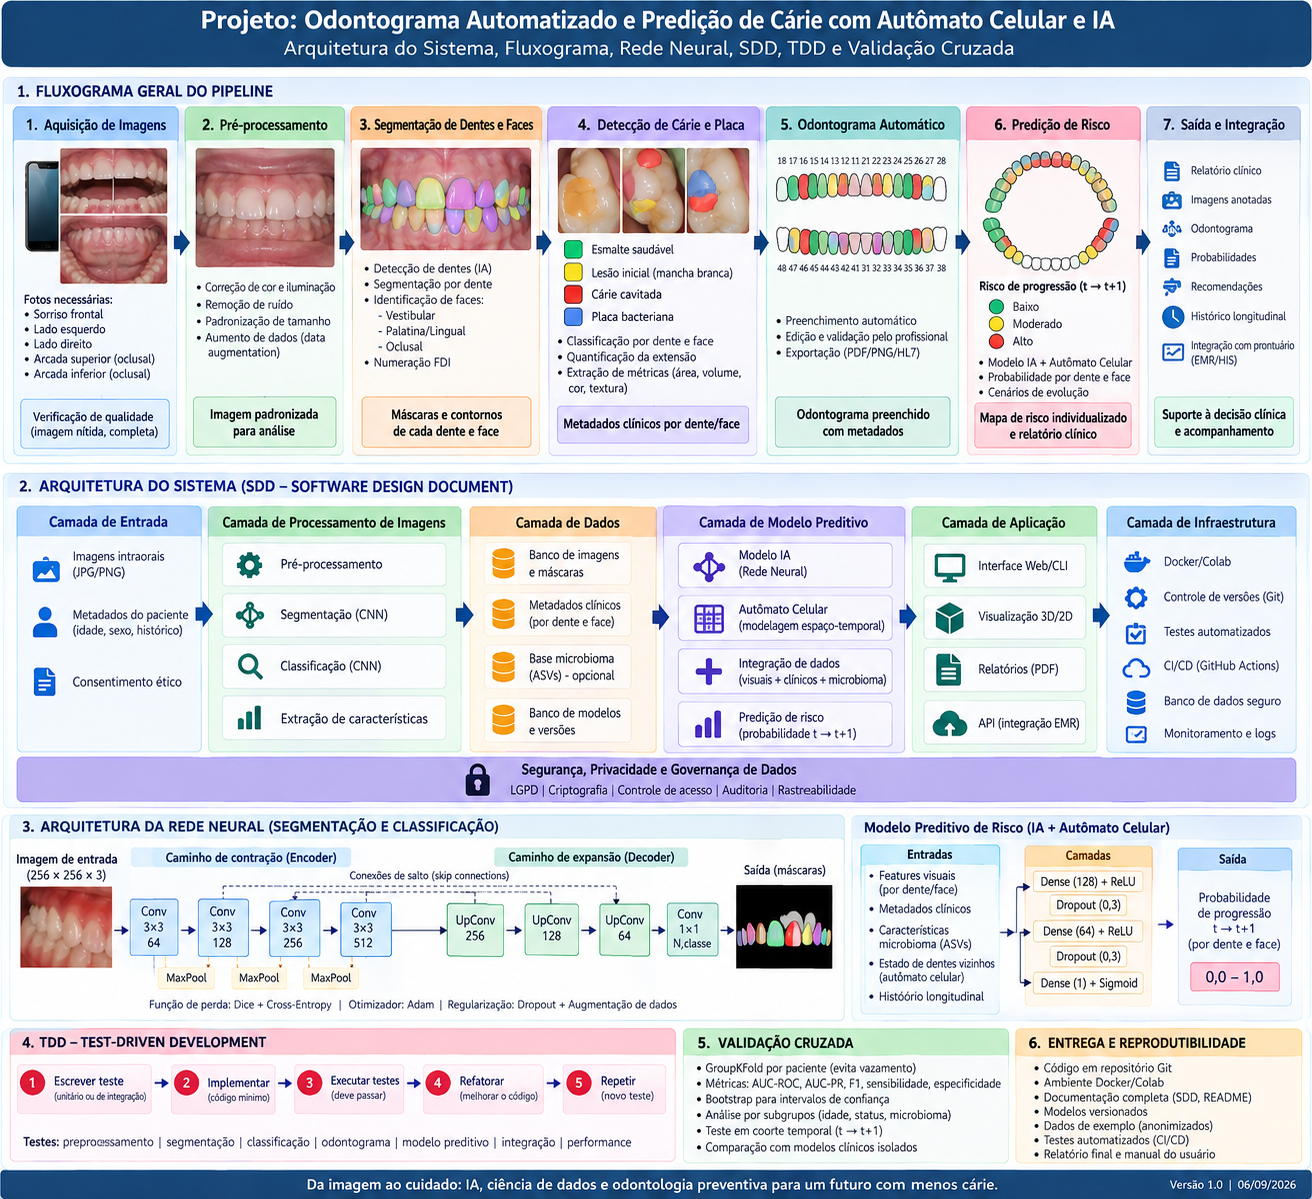

Esta versão funde formalmente duas bases:

1. `OdontoCA v1.2` — arquitetura, SDD/TDD, topologia FDI, odontograma,
   autômato, validação por paciente, FHIR e gates.
2. `SingleTooth_ECC_FULL_PIPELINE_v3_2_AUDIT_PATCH` — reprodução clínica,
   Qiita 14341, BIOM/ASV, ponte determinística de SampleIDs, modelos
   clínico/microbioma/combinado, auditoria below-chance e bootstrap incremental.

**Correção metodológica central da v1.3:** filtragem de ASVs, CLR, escala,
PCA e tuning passam a ocorrer **dentro do pipeline ajustado em cada fold
interno**, evitando o pré-processamento parcialmente não aninhado da v3.2.

# 0. Perfis de execução

| Perfil | Clínica real | Qiita/BIOM | Imagem | Uso |
|---|---:|---:|---:|---|
| `CI_SMOKE` | não | sintético | não | gate rápido e offline |
| `REPRO_DATASET` | sim | não | não | reproduzir 2.504→2.284→997/84 |
| `MICROBIOME_RESEARCH` | sim | sim | não | braço clínico + microbioma |
| `IMAGE_DATASET_AUDIT` | não | não | metadados / opcional ZIP | auditoria visual |
| `FULL_RESEARCH` | sim | sim | sim | pipeline completo |

No `CI_SMOKE`, usamos 3 folds externos, 2 internos e 200 bootstraps.
Nos perfis de pesquisa real, o padrão é 5 folds externos, 3 internos
e 5.000 bootstraps.

# 1. SDD 3.0 — arquitetura e requisitos

## 1.1 Fluxo ponta a ponta

`Aquisição → QA visual → Segmentação/FDI → Detecção de cárie → Odontograma`

`Table_S1 → dente individual → transições → vizinhança → CA probabilístico`

`Qiita 14341 → ponte SampleID → matriz ASV → CLR aninhado → modelos`

`OOF por criança → bootstrap → below-chance audit → compliance → FHIR`

## 1.2 Requisitos rastreáveis

| ID | Requisito |
|---|---|
| FR-001 | cinco vistas intraorais normalizadas |
| FR-002 | topologia FDI e vizinhança anatômica |
| FR-003 | schema mestre e odontograma com chave única |
| FR-004 | reconstrução temporal estritamente consecutiva |
| FR-005 | autômato celular probabilístico interpretável |
| FR-006 | validação agrupada por criança/paciente |
| FR-007 | comparador clínico-espacial |
| FR-008 | ponte determinística SampleID clínico ↔ BIOM |
| FR-009 | preprocessing microbioma completamente aninhado |
| FR-010 | modelos clínico, microbioma e combinado |
| FR-011 | auditoria de resultado abaixo do acaso |
| FR-012 | bootstrap clusterizado por criança |
| FR-013 | exportação experimental FHIR RiskAssessment |
| FR-014 | auditoria do benchmark visual |
| FR-015 | treinamento visual opcional e isolado |
| FR-016 | backend SegmentAnyTooth opcional/licenciado |
| FR-017 | proibição de fusão entre coortes não pareadas |
| DATA-001 | proveniência + hashes |
| DATA-002 | guardrail contra variáveis futuras |
| DATA-003 | reprodução das contagens publicadas |
| DATA-004 | alinhamento exato SampleID × ASV |
| ML-001 | seleção explícita de P(y=1) |
| ML-002 | PR-AUC, ROC-AUC, Brier, log loss OOF |
| ML-003 | calibração e incerteza por bootstrap |
| ML-004 | nested preprocessing sem leakage |
| SAFE-001 | placa/faces bloqueadas sem ground truth |
| SAFE-002 | nenhuma alegação clínica automática |
| NFR-001 | determinismo por seed |
| NFR-002 | perfil offline executável |
| NFR-003 | pacote final auditável |
| GOV-001 | checklist de conformidade item a item |

# 2. Decisões científicas

1. `HostGroup`, `Future_Status_Tooth` e `Time_to_decay` permanecem apenas
   para auditoria e nunca entram nos preditores.
2. O alvo positivo é explicitamente `1 = H→C`.
3. `predict_proba[:,1]` não é assumido; a coluna positiva é localizada
   por `estimator.classes_`.
4. `1 - AUC` pode ser calculado apenas como diagnóstico de orientação,
   nunca como desempenho reportável.
5. Datasets visual e longitudinal não são pareados. A fusão real é
   bloqueada até existir a mesma chave paciente-visita-dente nas modalidades.
6. Metas de desempenho são metas de aceitação, não resultados presumidos.

# 2.1 Fluxograma detalhado das camadas do estudo

A figura abaixo integra a arquitetura de engenharia e o desenho metodológico do
**OdontoCA v1.3 FULL RESEARCH**. O fluxograma passa a fazer parte formal do
protocolo do estudo e representa, em uma única visão, as camadas de dados,
processamento, modelagem, validação, guardrails, critérios de aceitação e
saídas reproduzíveis.

Os principais refinamentos representados são:

1. **Guardrail anti-vazamento estrito (L6 e L10).** O processamento
taxonômico é ajustado exclusivamente dentro dos folds de treinamento, e a
fusão multimodal é bloqueada quando as modalidades não compartilham a mesma
coorte e a chave `patient_id + visit_id + tooth_fdi`.

2. **Limpeza granular de dados (L3).** O pipeline separa registros dentários
individuais, exclui explicitamente `T5161`, reconstrói a série temporal por
criança e dente e conserva apenas transições consecutivas com
`Δtimepoint = 1` antes de definir o alvo `H→C`.

3. **Critérios de aceitação binários (L12).** Nenhum modelo é promovido
quando existe `FAIL`, sobreposição de pacientes ou evidência de leakage.
`SKIP` é admissível apenas em perfis que deliberadamente não carregam o
dataset real. Promoção clínica permanece bloqueada sem validação externa.

4. **Auditoria below-chance (L11).** A orientação da classe positiva é
verificada por `estimator.classes_`; `1-AUC` é permitido apenas como
diagnóstico e nunca como correção pós-hoc do desempenho.

## Figura — Fluxograma operacional e metodológico do OdontoCA v1.3


<div style="text-align:center; margin:20px 0;">
  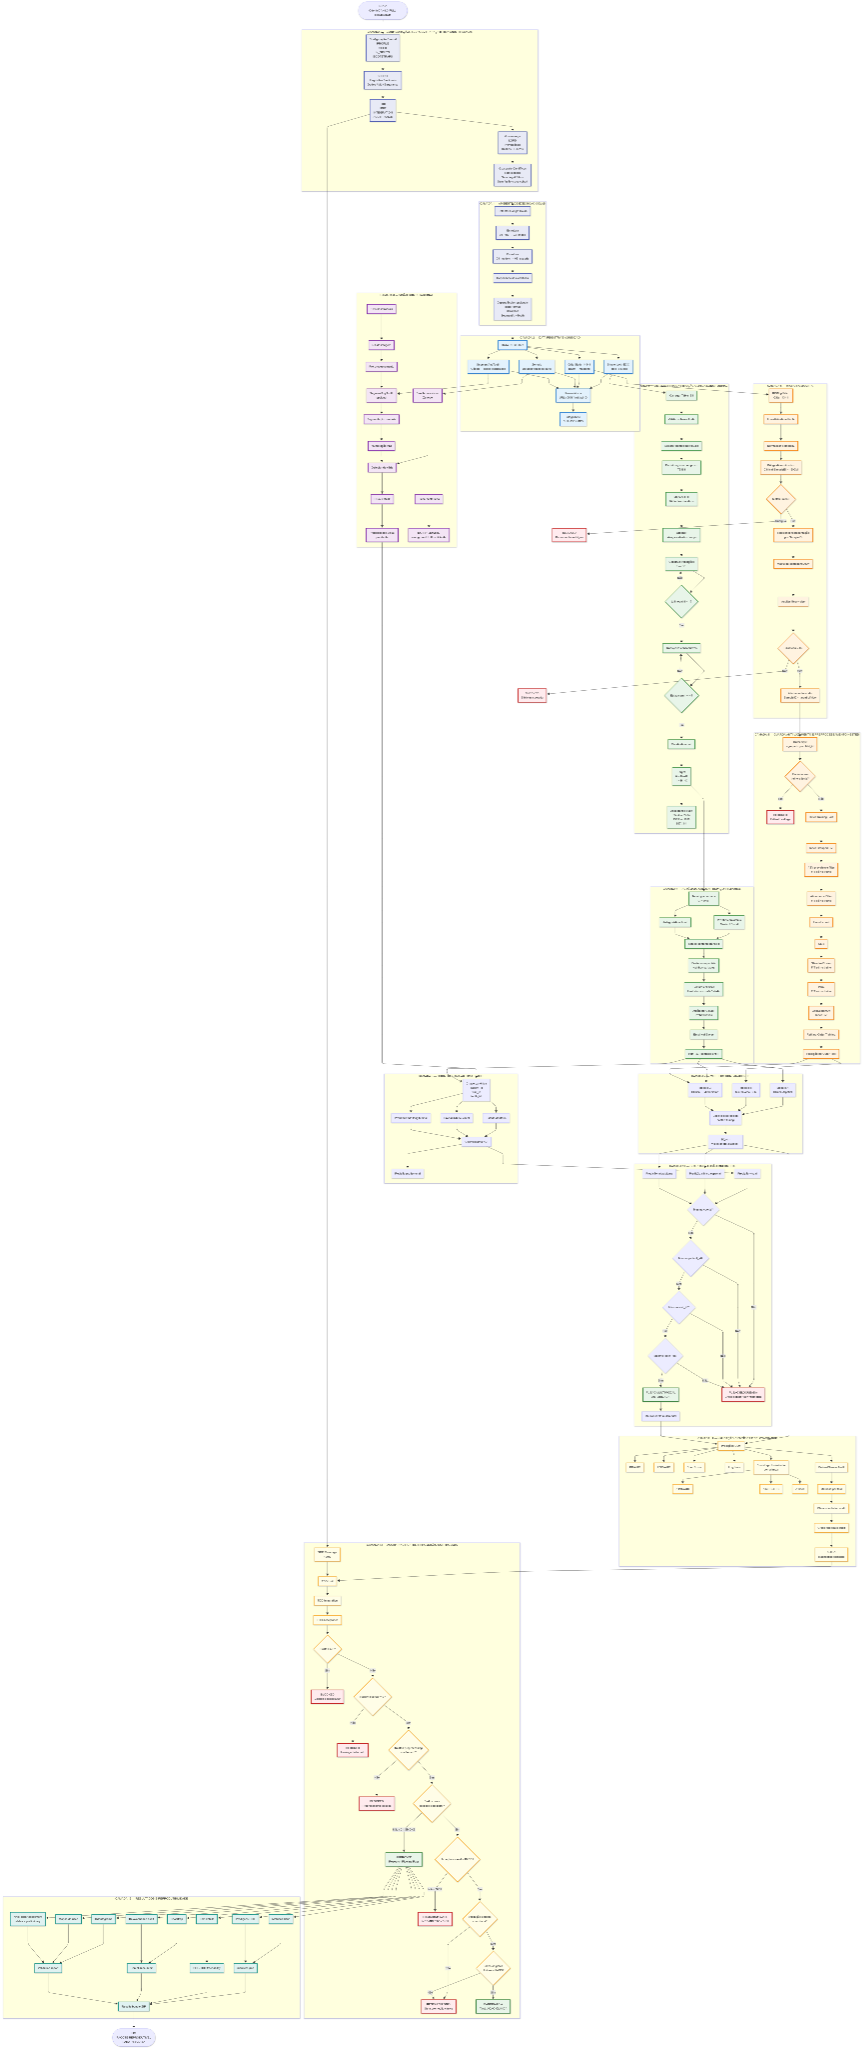
</div>


**Leitura da figura.** As camadas L0–L2 tratam de engenharia, governança e
aquisição; L3–L7 formam o núcleo longitudinal e microbiológico; L8–L10
cobrem visão computacional, odontograma e fusão multimodal; L11–L12
implementam validação científica e acceptance gates; L13 consolida os
artefatos reproduzíveis do estudo.

> **Nota metodológica:** `APPROVED` significa aprovação do pipeline para
> pesquisa no perfil executado. Não significa validação clínica.

In [ ]:
# 3. Configuração central
from dataclasses import dataclass, asdict
from pathlib import Path
from datetime import datetime, timezone
import os, sys, json, random, hashlib, platform, subprocess, re, zipfile, warnings, shutil

@dataclass
class Config:
    PROFILE: str = "CI_SMOKE"
    SEED: int = 20260906
    STRICT: bool = True
    DOWNLOAD_IMAGE_BENCHMARK: bool = False
    TRAIN_IMAGE_MODEL: bool = False
    IMAGE_EPOCHS: int = 30
    IMAGE_SIZE: int = 640
    SEGMENT_ANY_TOOTH: bool = False
    SEGMENT_WEIGHT_DIR: str = "/content/segmentanytooth_weights"
    QIITA_STUDY_ID: int = 14341
    QIITA_PREFERRED_ARTIFACT_ID: str = "214894"
    LOCAL_TABLE_S1: str = ""
    LOCAL_QIITA_ZIP: str = ""

CFG = Config()

if CFG.PROFILE == "CI_SMOKE":
    OUTER_FOLDS, INNER_FOLDS, BOOTSTRAPS = 3, 2, 200
else:
    OUTER_FOLDS, INNER_FOLDS, BOOTSTRAPS = 5, 3, 5000

ALLOW_NETWORK = CFG.PROFILE != "CI_SMOKE"
LOAD_REAL_CLINICAL = CFG.PROFILE in {"REPRO_DATASET","MICROBIOME_RESEARCH","FULL_RESEARCH"}
LOAD_REAL_MICRO = CFG.PROFILE in {"MICROBIOME_RESEARCH","FULL_RESEARCH"}
AUDIT_IMAGE_DATASET = CFG.PROFILE in {"IMAGE_DATASET_AUDIT","FULL_RESEARCH"}

IN_COLAB = "google.colab" in sys.modules
BASE = Path("/content/OdontoCA_v1_3" if IN_COLAB else "/tmp/OdontoCA_v1_3").resolve()
DIRS = {
    "raw":BASE/"00_raw",
    "clinical":BASE/"01_clinical",
    "micro":BASE/"02_microbiome",
    "image":BASE/"03_image",
    "models":BASE/"04_models",
    "figures":BASE/"05_figures",
    "reports":BASE/"06_reports",
    "tests":BASE/"07_tests",
    "exports":BASE/"08_exports",
}
for p in DIRS.values():
    p.mkdir(parents=True, exist_ok=True)

random.seed(CFG.SEED)
os.environ["PYTHONHASHSEED"] = str(CFG.SEED)

SOURCE_NOTEBOOK_HASHES = {"OdontoCA_v1_2_SDD_TDD_MULTIMODAL_VALIDATED_EXECUTED(1).ipynb": "0bbaa310191e3366b5ffe61c261b23219b1e84c73d48dd4c65711be73255eb77", "SingleTooth_ECC_FULL_PIPELINE_v3_2_AUDIT_PATCH(1).ipynb": "ea7ce5f358b536a821d930e7a07dee454914e63a21ac132139b0725a6f0e2b84"}

TARGETS = {
    "PR_AUC_MIN":0.78,
    "ROC_AUC_MIN":0.88,
    "BRIER_MAX":0.085,
    "DICE_MIN":0.82,
}

print(json.dumps({
    "profile":CFG.PROFILE,
    "outer_folds":OUTER_FOLDS,
    "inner_folds":INNER_FOLDS,
    "bootstraps":BOOTSTRAPS,
    "base":str(BASE),
}, indent=2))

{
  "profile": "CI_SMOKE",
  "outer_folds": 3,
  "inner_folds": 2,
  "bootstraps": 200,
  "base": "/content/OdontoCA_v1_3"
}


In [ ]:
# 4. Dependências — lazy install para não penalizar CI_SMOKE
import importlib.util

BASE_PACKAGES = {
    "numpy":"numpy",
    "pandas":"pandas",
    "scikit-learn":"sklearn",
    "openpyxl":"openpyxl",
    "requests":"requests",
    "matplotlib":"matplotlib",
    "scipy":"scipy",
}

def ensure_packages(mapping):
    missing = [pkg for pkg,mod in mapping.items() if importlib.util.find_spec(mod) is None]
    if missing:
        if not ALLOW_NETWORK:
            raise RuntimeError("Pacotes ausentes no CI_SMOKE: " + ", ".join(missing))
        subprocess.run([sys.executable,"-m","pip","install","-q",*missing], check=True)
    return missing

ensure_packages(BASE_PACKAGES)

import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import sklearn

from scipy.stats import beta as beta_dist
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    precision_recall_curve, roc_curve
)

warnings.filterwarnings("ignore")

# 5. Especificação TDD antes da implementação

A tabela abaixo é a especificação de testes. As funções de teste são
implementadas depois dos módulos produtivos e executadas no final.

In [ ]:
TDD_SPEC = pd.DataFrame([
    ["TDD-001","UNIT","FR-001","normalização das cinco vistas"],
    ["TDD-002","UNIT","FR-002","20 dentes decíduos e vizinhança válida"],
    ["TDD-003","UNIT","FR-002","antagonistas simétricos"],
    ["TDD-004","UNIT","FR-003","schema mestre válido"],
    ["TDD-005","UNIT","FR-003","odontograma rejeita chave duplicada"],
    ["TDD-006","UNIT","SAFE-001","placa bloqueada sem ground truth"],
    ["TDD-007","UNIT","DATA-002","variáveis futuras não entram no modelo"],
    ["TDD-008","INTEGRATION","FR-004","somente transições Δt=1"],
    ["TDD-009","INTEGRATION","FR-005","probabilidades CA em [0,1]"],
    ["TDD-010","INTEGRATION","FR-006","zero overlap de pacientes"],
    ["TDD-011","INTEGRATION","ML-002","OOF completo"],
    ["TDD-012","UNIT","ML-001","classe positiva localizada por classes_"],
    ["TDD-013","UNIT","ML-004","seletor ASV usa apenas treino"],
    ["TDD-014","INTEGRATION","FR-009","pipeline microbioma é nested"],
    ["TDD-015","INTEGRATION","FR-010","três modelos geram OOF"],
    ["TDD-016","INTEGRATION","FR-011","below-chance não inverte resultado"],
    ["TDD-017","INTEGRATION","FR-012","bootstrap incremental válido"],
    ["TDD-018","UNIT","FR-013","FHIR é preliminary/research-only"],
    ["TDD-019","UNIT","FR-017","fusão cross-cohort é bloqueada"],
    ["TDD-020","UNIT","FR-008","normalização SampleID determinística"],
    ["TDD-021","UNIT","FR-008","match ambíguo não é aceito"],
    ["TDD-022","UNIT","NFR-001","mesma seed → mesmas predições"],
    ["TDD-023","UNIT","NFR-002","CI_SMOKE não requer rede"],
    ["TDD-024","ACCEPTANCE","DATA-003","contagens clínicas reais reproduzidas"],
    ["TDD-025","ACCEPTANCE","DATA-004","SampleID × ASV alinhado quando real"],
    ["TDD-026","UNIT","SAFE-002","metas não viram gate clínico"],
], columns=["test_id","level","requirement","spec"])
display(TDD_SPEC)

,test_id,level,requirement,spec
0,TDD-001,UNIT,FR-001,normalização das cinco vistas
1,TDD-002,UNIT,FR-002,20 dentes decíduos e vizinhança válida
2,TDD-003,UNIT,FR-002,antagonistas simétricos
3,TDD-004,UNIT,FR-003,schema mestre válido
4,TDD-005,UNIT,FR-003,odontograma rejeita chave duplicada
5,TDD-006,UNIT,SAFE-001,placa bloqueada sem ground truth
6,TDD-007,UNIT,DATA-002,variáveis futuras não entram no modelo
7,TDD-008,INTEGRATION,FR-004,somente transições Δt=1
8,TDD-009,INTEGRATION,FR-005,"probabilidades CA em [0,1]"
9,TDD-010,INTEGRATION,FR-006,zero overlap de pacientes


# 6. Schema mestre, FDI e contratos

In [ ]:
MASTER_SCHEMA = {
    "patient_id":{"required":True},
    "visit_id":{"required":True},
    "visit_timestamp":{"required":True},
    "tooth_fdi":{"required":True},
    "surface_code":{"required":False,"domain":{"O","V","L","P","M","D"}},
    "image_path":{"required":False},
    "mask_path":{"required":False},
    "visual_lesion_class":{"required":False,"domain":{0,1,2,3}},
    "lesion_area_px":{"required":False,"min":0.0},
    "plaque_coverage_pct":{"required":False,"min":0.0,"max":100.0},
    "next_visit_class":{"required":False,"domain":{0,1,2}},
}

VALIDATED_TARGETS = {"caries"}
EXPERIMENTAL_TARGETS = {"plaque","surface_diagnosis"}

class UnsupportedGroundTruth(RuntimeError):
    pass

class CrossCohortFusionError(RuntimeError):
    pass

def require_validated_target(target):
    t = str(target).strip().lower()
    if t not in VALIDATED_TARGETS:
        raise UnsupportedGroundTruth(f"Target não validado: {t}")
    return t

def validate_master_schema(df):
    errors = []
    for k,spec in MASTER_SCHEMA.items():
        if spec.get("required") and k not in df.columns:
            errors.append(f"missing:{k}")
    if errors:
        return {"ok":False,"errors":errors}
    if df.duplicated(["patient_id","visit_id","tooth_fdi"]).any():
        errors.append("duplicate_patient_visit_tooth")
    if "surface_code" in df:
        bad = set(df["surface_code"].dropna().astype(str)) - MASTER_SCHEMA["surface_code"]["domain"]
        if bad: errors.append(f"bad_surface:{sorted(bad)}")
    if "lesion_area_px" in df:
        x = pd.to_numeric(df["lesion_area_px"],errors="coerce")
        if (x<0).fillna(False).any(): errors.append("negative_lesion_area")
    if "plaque_coverage_pct" in df:
        x = pd.to_numeric(df["plaque_coverage_pct"],errors="coerce")
        if ((x<0)|(x>100)).fillna(False).any(): errors.append("plaque_range")
    return {"ok":not errors,"errors":errors}

UPPER = ["T55","T54","T53","T52","T51","T61","T62","T63","T64","T65"]
LOWER = ["T85","T84","T83","T82","T81","T71","T72","T73","T74","T75"]
ARCHES = {"upper":UPPER,"lower":LOWER}
ALL_PRIMARY = UPPER + LOWER

NEIGHBORS = {}
for seq in ARCHES.values():
    for i,t in enumerate(seq):
        NEIGHBORS[t] = (
            ([seq[i-1]] if i>0 else []) +
            ([seq[i+1]] if i<len(seq)-1 else [])
        )

ANTAGONISTS = {
    "T55":"T85","T54":"T84","T53":"T83","T52":"T82","T51":"T81",
    "T61":"T71","T62":"T72","T63":"T73","T64":"T74","T65":"T75",
}
ANTAGONISTS.update({v:k for k,v in list(ANTAGONISTS.items())})

VIEW_ALIASES = {
    "front":"front","frontal":"front",
    "left":"left","left lateral":"left","lateral esquerda":"left",
    "right":"right","right lateral":"right","lateral direita":"right",
    "upper":"upper","maxillary occlusal":"upper","oclusal superior":"upper",
    "lower":"lower","mandibular occlusal":"lower","oclusal inferior":"lower",
}

def normalize_view(view):
    k = re.sub(r"\s+"," ",str(view).strip().lower())
    if k not in VIEW_ALIASES:
        raise ValueError(f"Vista inválida: {view}")
    return VIEW_ALIASES[k]

def build_odontogram(records):
    d = pd.DataFrame(records)
    req = {"patient_id","visit_id","tooth_fdi","state"}
    assert not (req-set(d.columns)), f"Campos ausentes: {sorted(req-set(d.columns))}"
    d["tooth_fdi"] = d["tooth_fdi"].astype(str).str.replace("T","",regex=False)
    valid = {x[1:] for x in ALL_PRIMARY}
    bad = set(d["tooth_fdi"]) - valid
    assert not bad, f"FDI inválido: {sorted(bad)}"
    assert not d.duplicated(["patient_id","visit_id","tooth_fdi"]).any()
    return d.sort_values(["patient_id","visit_id","tooth_fdi"]).reset_index(drop=True)

# 7. Fonte clínica Single-tooth ECC

In [ ]:
SUPPLEMENT_URLS = {
    "Table_S1.xlsx":
        "https://raw.githubusercontent.com/HuangShiLab/Single-tooth-ECC/main/Figures_and_Tables_in_Manuscript/Table_S1.xlsx",
}
REQUIRED_SOURCE = [
    "SampleID","HostGroup","Status_Host","Status_Tooth",
    "dmfs_Host","dmfs_Tooth","Month","Timepoint","Position",
    "NicheICM","NicheUL","NicheLR","HostID",
    "Future_Status_Tooth","NicheAP","Position_Tooth",
    "X","Y","Z","spatial_dist_weighted_mean_dmfs",
    "sum_dmfs","sum_ns_dt","sum_s_dt","Time_to_decay"
]
FORBIDDEN_PREDICTORS = {"HostGroup","Future_Status_Tooth","Time_to_decay",
                        "future_status_source","time_to_decay_source",
                        "state_t1","progression_event"}

def sha256_file(path,chunk=1024*1024):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for b in iter(lambda:f.read(chunk),b""):
            h.update(b)
    return h.hexdigest()

def network_guard():
    if not ALLOW_NETWORK:
        raise RuntimeError("Rede bloqueada no CI_SMOKE.")

def requests_session():
    network_guard()
    import requests
    from requests.adapters import HTTPAdapter
    from urllib3.util.retry import Retry
    s=requests.Session()
    s.mount("https://",HTTPAdapter(max_retries=Retry(
        total=4,backoff_factor=1,status_forcelist=[429,500,502,503,504]
    )))
    return s

def stream_download(url,dest,timeout=180):
    s=requests_session()
    dest=Path(dest)
    tmp=dest.with_suffix(dest.suffix+".part")
    with s.get(url,stream=True,timeout=timeout) as r:
        r.raise_for_status()
        with open(tmp,"wb") as f:
            for chunk in r.iter_content(1024*1024):
                if chunk:f.write(chunk)
    tmp.replace(dest)
    return dest

def load_table_s1():
    target = DIRS["raw"]/"Table_S1.xlsx"
    local = Path(CFG.LOCAL_TABLE_S1) if CFG.LOCAL_TABLE_S1 else None
    if local and local.exists():
        shutil.copy2(local,target)
    if not target.exists():
        stream_download(SUPPLEMENT_URLS["Table_S1.xlsx"],target)
    xls=pd.ExcelFile(target)
    assert "all_metadata" in xls.sheet_names
    meta=pd.read_excel(target,sheet_name="all_metadata")
    meta.columns=[str(c).strip() for c in meta.columns]
    missing=[c for c in REQUIRED_SOURCE if c not in meta.columns]
    assert not missing,f"Campos ausentes: {missing}"
    return meta,target

In [ ]:
# 8. Mapa dentário e reconstrução longitudinal exata
def build_tooth_map(meta):
    rows=[]
    for arch,seq in ARCHES.items():
        for idx,tooth in enumerate(seq):
            src=meta.loc[meta["Position"].eq(tooth)]
            assert len(src)>0,tooth
            r=src.iloc[0]
            rows.append({
                "tooth_position":tooth,
                "tooth_fdi":int(tooth[1:]),
                "tooth_type_index":int(str(r["Position_Tooth"])[1:]),
                "arch":arch,"arch_index":idx,
                "niche_icm":r["NicheICM"],"niche_ul":r["NicheUL"],
                "niche_lr":r["NicheLR"],"niche_ap":r["NicheAP"],
                "x":float(r["X"]),"y":float(r["Y"]),"z":float(r["Z"]),
                "neighbor_prev_tooth":seq[idx-1] if idx>0 else np.nan,
                "neighbor_next_tooth":seq[idx+1] if idx<len(seq)-1 else np.nan,
            })
    return pd.DataFrame(rows)

def clean_single_tooth(meta):
    tooth_map=build_tooth_map(meta)
    composite=meta.loc[meta["Position"].eq("T5161")].copy()
    single=meta.loc[meta["Position"].isin(tooth_map["tooth_position"])].copy()
    single=single.merge(
        tooth_map,left_on="Position",right_on="tooth_position",
        how="left",validate="many_to_one"
    )
    clean=pd.DataFrame({
        "sample_id":single["SampleID"].astype(str),
        "child_id":single["HostID"].astype(str),
        "timepoint":single["Timepoint"].astype(str),
        "time_index":single["Timepoint"].astype(str).str.extract(r"(\d+)")[0].astype(int),
        "age_months":pd.to_numeric(single["Month"],errors="coerce"),
        "tooth_position":single["tooth_position"],
        "tooth_fdi":single["tooth_fdi"],
        "tooth_type_index":single["tooth_type_index"],
        "arch":single["arch"],"arch_index":single["arch_index"],
        "niche_icm":single["NicheICM"],"niche_ul":single["NicheUL"],
        "niche_lr":single["NicheLR"],"niche_ap":single["NicheAP"],
        "x":pd.to_numeric(single["X"],errors="coerce"),
        "y":pd.to_numeric(single["Y"],errors="coerce"),
        "z":pd.to_numeric(single["Z"],errors="coerce"),
        "tooth_status":single["Status_Tooth"].astype(str),
        "tooth_state_code":single["Status_Tooth"].map({"H":0,"C":1}),
        "tooth_dmfs":pd.to_numeric(single["dmfs_Tooth"],errors="coerce"),
        "host_status":single["Status_Host"].astype(str),
        "host_dmfs":pd.to_numeric(single["dmfs_Host"],errors="coerce"),
        "spatial_weighted_dmfs":pd.to_numeric(single["spatial_dist_weighted_mean_dmfs"],errors="coerce"),
        "sum_dmfs":pd.to_numeric(single["sum_dmfs"],errors="coerce"),
        "sum_ns_dt":pd.to_numeric(single["sum_ns_dt"],errors="coerce"),
        "sum_s_dt":pd.to_numeric(single["sum_s_dt"],errors="coerce"),
        "host_group_source":single["HostGroup"],
        "future_status_source":single["Future_Status_Tooth"],
        "time_to_decay_source":pd.to_numeric(single["Time_to_decay"],errors="coerce"),
        "neighbor_prev_tooth":single["neighbor_prev_tooth"],
        "neighbor_next_tooth":single["neighbor_next_tooth"],
    })
    assert clean.duplicated(["child_id","tooth_position","timepoint"]).sum()==0
    return tooth_map,composite,clean

def build_transitions(clean):
    lookup=clean.set_index(
        ["child_id","timepoint","tooth_position"]
    )[["tooth_status","tooth_dmfs"]]
    s=clean.sort_values(
        ["child_id","tooth_position","time_index","sample_id"]
    ).copy()
    g=s.groupby(["child_id","tooth_position"],sort=False)

    for source,target in [
        ("sample_id","sample_id_t1"),("timepoint","timepoint_t1"),
        ("time_index","time_index_t1"),("age_months","age_months_t1"),
        ("tooth_status","state_t1"),("tooth_state_code","state_code_t1"),
        ("tooth_dmfs","dmfs_tooth_t1"),("host_status","host_status_t1"),
        ("host_dmfs","host_dmfs_t1")
    ]:
        s[target]=g[source].shift(-1)

    obs=s.loc[s["sample_id_t1"].notna()].copy()
    obs["delta_timepoints"]=obs["time_index_t1"]-obs["time_index"]
    obs["delta_months"]=obs["age_months_t1"]-obs["age_months"]
    obs["progression_event"]=(
        (obs["tooth_status"]=="H")&(obs["state_t1"]=="C")
    ).astype(int)
    obs["transition_class"]=obs["tooth_status"]+"->"+obs["state_t1"].astype(str)

    def get_neighbor(row,which,field):
        tooth=row[which]
        if pd.isna(tooth):return np.nan
        try:return lookup.loc[(row["child_id"],row["timepoint"],tooth),field]
        except KeyError:return np.nan

    obs["neighbor_prev_state_t"]=obs.apply(
        lambda r:get_neighbor(r,"neighbor_prev_tooth","tooth_status"),axis=1)
    obs["neighbor_prev_dmfs_t"]=obs.apply(
        lambda r:get_neighbor(r,"neighbor_prev_tooth","tooth_dmfs"),axis=1)
    obs["neighbor_next_state_t"]=obs.apply(
        lambda r:get_neighbor(r,"neighbor_next_tooth","tooth_status"),axis=1)
    obs["neighbor_next_dmfs_t"]=obs.apply(
        lambda r:get_neighbor(r,"neighbor_next_tooth","tooth_dmfs"),axis=1)
    obs["n_neighbors_observed_t"]=obs[
        ["neighbor_prev_state_t","neighbor_next_state_t"]
    ].notna().sum(axis=1)

    trans=pd.DataFrame({
        "transition_id":obs["child_id"]+"|"+obs["tooth_position"]+"|"+
            obs["timepoint"]+"->"+obs["timepoint_t1"].astype(str),
        "child_id":obs["child_id"],"tooth_position":obs["tooth_position"],
        "tooth_fdi":obs["tooth_fdi"],"tooth_type_index":obs["tooth_type_index"],
        "arch":obs["arch"],"arch_index":obs["arch_index"],
        "niche_icm":obs["niche_icm"],"niche_ul":obs["niche_ul"],
        "niche_lr":obs["niche_lr"],"niche_ap":obs["niche_ap"],
        "x":obs["x"],"y":obs["y"],"z":obs["z"],
        "sample_id_t":obs["sample_id"],"timepoint_t":obs["timepoint"],
        "time_index_t":obs["time_index"],"age_months_t":obs["age_months"],
        "state_t":obs["tooth_status"],"state_code_t":obs["tooth_state_code"],
        "dmfs_tooth_t":obs["tooth_dmfs"],"host_status_t":obs["host_status"],
        "host_dmfs_t":obs["host_dmfs"],
        "spatial_weighted_dmfs_t":obs["spatial_weighted_dmfs"],
        "sum_dmfs_t":obs["sum_dmfs"],"sum_ns_dt_t":obs["sum_ns_dt"],
        "sum_s_dt_t":obs["sum_s_dt"],
        "neighbor_prev_tooth":obs["neighbor_prev_tooth"],
        "neighbor_prev_state_t":obs["neighbor_prev_state_t"],
        "neighbor_prev_dmfs_t":obs["neighbor_prev_dmfs_t"],
        "neighbor_next_tooth":obs["neighbor_next_tooth"],
        "neighbor_next_state_t":obs["neighbor_next_state_t"],
        "neighbor_next_dmfs_t":obs["neighbor_next_dmfs_t"],
        "n_neighbors_observed_t":obs["n_neighbors_observed_t"],
        "sample_id_t1":obs["sample_id_t1"],"timepoint_t1":obs["timepoint_t1"],
        "time_index_t1":obs["time_index_t1"],"age_months_t1":obs["age_months_t1"],
        "delta_timepoints":obs["delta_timepoints"],"delta_months":obs["delta_months"],
        "state_t1":obs["state_t1"],"state_code_t1":obs["state_code_t1"],
        "dmfs_tooth_t1":obs["dmfs_tooth_t1"],"host_status_t1":obs["host_status_t1"],
        "host_dmfs_t1":obs["host_dmfs_t1"],"progression_event":obs["progression_event"],
        "transition_class":obs["transition_class"],
        "host_group_source":obs["host_group_source"],
        "future_status_source_t":obs["future_status_source"],
        "time_to_decay_source_t":obs["time_to_decay_source"],
    })
    one=trans.loc[trans["delta_timepoints"].eq(1)].copy()
    onset=one.loc[one["state_t"].eq("H")].copy()
    return trans,one,onset

EXPECTED_COUNTS = {
    "metadata_rows":2504,"children":89,"composite_T5161":220,
    "single_tooth_rows":2284,"all_observed_transitions":1388,
    "one_step_transitions":1160,"H_to_H":913,"H_to_C":84,
    "C_to_C":163,"C_to_H":0,"onset_rows":997,
}

# 9. Autômato celular interpretável

In [ ]:
def add_ca_features(onset):
    ca=onset.copy()
    ca["neighbor_prev_caries"]=(ca["neighbor_prev_state_t"]=="C").astype(int)
    ca["neighbor_next_caries"]=(ca["neighbor_next_state_t"]=="C").astype(int)
    ca["neighbor_caries_count"]=ca["neighbor_prev_caries"]+ca["neighbor_next_caries"]
    return ca

def ca_rule_predict(train,test,prior_strength=20.0):
    global_p=(train["progression_event"].sum()+0.5)/(len(train)+1)

    def table(keys):
        g=train.groupby(keys,dropna=False)["progression_event"].agg(["sum","count"])
        g["p"]=(g["sum"]+prior_strength*global_p)/(g["count"]+prior_strength)
        return g["p"].to_dict()

    t3=table(["niche_icm","host_status_t","neighbor_caries_count"])
    t2=table(["niche_icm","host_status_t"])
    t1=table(["niche_icm"])

    out=[]
    for _,r in test.iterrows():
        k3=(r["niche_icm"],r["host_status_t"],r["neighbor_caries_count"])
        k2=(r["niche_icm"],r["host_status_t"])
        k1=r["niche_icm"]
        out.append(t3.get(k3,t2.get(k2,t1.get(k1,global_p))))
    return np.asarray(out,float)

def safe_group_splits(y,groups,requested):
    tmp=pd.DataFrame({"y":np.asarray(y,int),"g":np.asarray(groups,str)})
    gc=tmp.groupby("g")["y"].max()
    counts=gc.value_counts()
    if len(counts)<2:
        raise ValueError("Grupos positivos/negativos insuficientes.")
    n=min(int(requested),int(counts.min()))
    if n<2:raise ValueError("Menos de 2 folds possíveis.")
    return n

def ca_oof(ca,requested=5,seed=20260906):
    y=ca["progression_event"].astype(int).to_numpy()
    g=ca["child_id"].astype(str).to_numpy()
    n=safe_group_splits(y,g,requested)
    cv=StratifiedGroupKFold(n_splits=n,shuffle=True,random_state=seed)
    pred=np.full(len(ca),np.nan)
    fold=np.full(len(ca),-1)
    for f,(tr,te) in enumerate(cv.split(ca,y,g)):
        assert set(g[tr]).isdisjoint(set(g[te]))
        pred[te]=ca_rule_predict(ca.iloc[tr],ca.iloc[te])
        fold[te]=f
    metrics={
        "model":"CA_probabilistic_rule","n":len(ca),"events":int(y.sum()),
        "prevalence":float(y.mean()),
        "PR_AUC":float(average_precision_score(y,pred)),
        "ROC_AUC":float(roc_auc_score(y,pred)),
        "Brier":float(brier_score_loss(y,pred)),
        "LogLoss":float(log_loss(y,np.clip(pred,1e-6,1-1e-6)),
        )
    }
    return metrics,pred,fold

# 10. Ponte Qiita e matriz microbiológica

In [ ]:
QIITA_PUBLIC_PAGE = f"https://qiita.ucsd.edu/public/?study_id={CFG.QIITA_STUDY_ID}"
QIITA_DOWNLOAD = f"https://qiita.ucsd.edu/public_download/?data=biom&study_id={CFG.QIITA_STUDY_ID}"

def canonical_clinical_id(raw,target_ids,explicit_map=None):
    explicit_map=explicit_map or {}
    target_ids=set(map(str,target_ids))
    upper={x.upper():x for x in target_ids}
    if raw is None:return None,"missing"
    s=str(raw).strip()
    if not s:return None,"empty"
    if s in target_ids:return s,"exact"
    su=s.upper()
    if su in upper:return upper[su],"case_normalized"

    tokens=[t for t in re.split(r"[._:/|\s-]+",su) if t]
    hits=list(dict.fromkeys(upper[t] for t in tokens if t in upper))
    if len(hits)==1:return hits[0],"namespace_token"

    embedded=re.findall(r"(?i)A\d{4,6}",s)
    hits=list(dict.fromkeys(upper[x.upper()] for x in embedded if x.upper() in upper))
    if len(hits)==1:return hits[0],"embedded_A_id"

    if s in explicit_map:return explicit_map[s],"qiita_mapping_file"
    return None,"unmatched"

def infer_artifact_id(path):
    path=Path(path)
    for part in reversed(path.parts):
        if re.fullmatch(r"\d{5,7}",str(part)):return str(part)
    m=re.search(r"(?<!\d)(\d{5,7})(?!\d)",path.name)
    return m.group(1) if m else ""

def ensure_biom_package():
    if importlib.util.find_spec("biom") is None:
        if not ALLOW_NETWORK:raise RuntimeError("biom-format ausente.")
        subprocess.run([sys.executable,"-m","pip","install","-q","biom-format"],check=True)
    from biom import load_table
    return load_table

def load_qiita_counts(target_ids):
    load_table=ensure_biom_package()
    qiita_zip=DIRS["raw"]/f"qiita_{CFG.QIITA_STUDY_ID}_biom_mapping.zip"
    qiita_dir=DIRS["raw"]/f"qiita_{CFG.QIITA_STUDY_ID}"
    qiita_dir.mkdir(exist_ok=True)

    local=Path(CFG.LOCAL_QIITA_ZIP) if CFG.LOCAL_QIITA_ZIP else None
    if local and local.exists():
        shutil.copy2(local,qiita_zip)

    if not qiita_zip.exists():
        s=requests_session()
        with s.get(QIITA_DOWNLOAD,stream=True,timeout=1200) as r:
            r.raise_for_status()
            with open(qiita_zip,"wb") as f:
                for chunk in r.iter_content(1024*1024):
                    if chunk:f.write(chunk)

    assert zipfile.is_zipfile(qiita_zip)
    if not any(qiita_dir.iterdir()):
        with zipfile.ZipFile(qiita_zip) as z:z.extractall(qiita_dir)

    biom_files=sorted(qiita_dir.rglob("*.biom"))
    assert biom_files,"Nenhum BIOM encontrado."

    target_ids=set(map(str,target_ids))
    biom_cache={}
    all_raw=set()
    for fp in biom_files:
        try:
            tbl=load_table(str(fp))
            biom_cache[str(fp)]=tbl
            all_raw.update(map(str,tbl.ids(axis="sample")))
        except Exception:
            pass

    # Mapping-file fallback determinístico.
    mapping_candidates=[]
    mapping_files=[
        p for p in qiita_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in {".txt",".tsv",".csv"}
    ]
    for mp in mapping_files:
        try:
            mdf=pd.read_csv(mp,sep=None,engine="python",dtype=str,nrows=200000)
        except Exception:
            continue
        if mdf.empty or len(mdf.columns)<2:continue

        raw_cols=[]
        for c in mdf.columns:
            vals=set(mdf[c].dropna().astype(str).str.strip())
            if vals & all_raw:raw_cols.append(c)
        if not raw_cols:continue

        for raw_col in raw_cols:
            for clin_col in mdf.columns:
                if clin_col==raw_col:continue
                tmp=mdf[[raw_col,clin_col]].dropna().copy()
                tmp.columns=["raw","clin"]
                tmp["raw"]=tmp["raw"].astype(str).str.strip()
                tmp["cid"]=tmp["clin"].map(
                    lambda x: canonical_clinical_id(x,target_ids)[0]
                )
                tmp=tmp[tmp["raw"].isin(all_raw)&tmp["cid"].notna()]
                for _,r in tmp.iterrows():
                    mapping_candidates.append((r["raw"],r["cid"]))

    explicit={}
    if mapping_candidates:
        mm=pd.DataFrame(mapping_candidates,columns=["raw","cid"]).drop_duplicates()
        counts=mm.groupby("raw")["cid"].nunique()
        good=set(counts[counts==1].index)
        explicit=(
            mm[mm["raw"].isin(good)]
            .drop_duplicates("raw").set_index("raw")["cid"].to_dict()
        )

    inventory=[]
    candidates=[]
    for fp,tbl in biom_cache.items():
        samples=list(map(str,tbl.ids(axis="sample")))
        sums=np.asarray(tbl.sum(axis="sample")).astype(float)
        resolved=[]
        collisions={}
        for sid in samples:
            cid,method=canonical_clinical_id(sid,target_ids,explicit)
            if cid:
                resolved.append(cid)
                collisions.setdefault(cid,[]).append(sid)
        collision_n=sum(len(set(v))>1 for v in collisions.values())
        aid=infer_artifact_id(fp)
        inventory.append({
            "artifact_id":aid,"path":fp,"filename":Path(fp).name,
            "n_samples":len(samples),
            "n_features":len(list(tbl.ids(axis="observation"))),
            "target_overlap":len(set(resolved)),
            "median_library_size":float(np.median(sums)) if len(sums) else np.nan,
            "is_all_biom":"all.biom" in Path(fp).name.lower(),
            "collision_count":collision_n,
            "preferred_artifact":aid==CFG.QIITA_PREFERRED_ARTIFACT_ID,
        })

    inv=pd.DataFrame(inventory)
    valid=inv[
        inv["target_overlap"].fillna(0).gt(0)&
        inv["collision_count"].fillna(0).eq(0)
    ].copy()
    if len(valid)==0:
        raise RuntimeError("Nenhum BIOM com pareamento determinístico.")

    # preferência configurável; fallback auditável.
    valid["preference"]=(
        10000*valid["preferred_artifact"].astype(int)+
        1000*valid["is_all_biom"].astype(int)+
        valid["target_overlap"].fillna(0)
    )
    valid=valid.sort_values(
        ["preference","target_overlap","median_library_size"],
        ascending=[False,False,False]
    )

    selected=[]
    covered=set()
    for _,r in valid.iterrows():
        tbl=biom_cache[r["path"]]
        resolved={}
        for raw_sid in map(str,tbl.ids(axis="sample")):
            cid,method=canonical_clinical_id(raw_sid,target_ids,explicit)
            if cid in target_ids:
                resolved[cid]=(raw_sid,method)
        new=set(resolved)-covered
        if new:
            rr=r.to_dict()
            rr["new_target_samples_added"]=len(new)
            selected.append(rr)
            covered |= new

    sel=pd.DataFrame(selected)

    # uma representação por SampleID.
    assign_rows=[]
    for _,r in sel.iterrows():
        tbl=biom_cache[r["path"]]
        sums=np.asarray(tbl.sum(axis="sample")).astype(float)
        samples=list(map(str,tbl.ids(axis="sample")))
        smap=dict(zip(samples,sums))
        for raw_sid in samples:
            cid,method=canonical_clinical_id(raw_sid,target_ids,explicit)
            if cid in target_ids:
                assign_rows.append({
                    "clinical_sample_id":cid,"raw_biom_sample_id":raw_sid,
                    "match_method":method,"artifact_id":r["artifact_id"],
                    "path":r["path"],"preference":r["preference"],
                    "library_size":smap.get(raw_sid,np.nan),
                })
    assign_all=pd.DataFrame(assign_rows)
    assign=(
        assign_all.sort_values(
            ["clinical_sample_id","preference","library_size"],
            ascending=[True,False,False]
        ).drop_duplicates("clinical_sample_id",keep="first")
    )
    assert not assign["clinical_sample_id"].duplicated().any()

    rows={}
    source=[]
    for _,a in assign.iterrows():
        tbl=biom_cache[a["path"]]
        raw=str(a["raw_biom_sample_id"])
        cid=str(a["clinical_sample_id"])
        vec=np.asarray(tbl.data(raw,axis="sample",dense=True)).astype(float)
        fids=list(map(str,tbl.ids(axis="observation")))
        row={fid:float(v) for fid,v in zip(fids,vec) if v>0}
        rows[cid]=row
        source.append({
            "clinical_sample_id":cid,"raw_biom_sample_id":raw,
            "artifact_id":a["artifact_id"],"match_method":a["match_method"],
            "n_nonzero_features":len(row),"library_size":sum(row.values())
        })

    counts=pd.DataFrame.from_dict(rows,orient="index").fillna(0.0).sort_index()
    counts.index.name="sample_id"
    assert counts.index.is_unique
    assert set(counts.index).issubset(target_ids)

    inv.to_csv(DIRS["micro"]/"qiita_artifact_inventory.csv",index=False)
    sel.to_csv(DIRS["micro"]/"qiita_selected_artifacts.csv",index=False)
    assign.to_csv(DIRS["micro"]/"sample_to_artifact_assignment.csv",index=False)
    pd.DataFrame(source).to_csv(DIRS["micro"]/"microbiome_source_by_sample.csv",index=False)
    counts.to_csv(DIRS["micro"]/"microbiome_counts_target.tsv.gz",sep="\t",compression="gzip")
    return counts,inv,sel,assign,qiita_zip

# 11. Preprocessing microbioma completamente aninhado

In [ ]:
class MicrobiomeCLRSelector(BaseEstimator,TransformerMixin):
    def __init__(self,prevalence_min=0.05,min_total=20.0,pseudocount=0.5,min_features=5,max_fallback=100):
        self.prevalence_min=prevalence_min
        self.min_total=min_total
        self.pseudocount=pseudocount
        self.min_features=min_features
        self.max_fallback=max_fallback

    def fit(self,X,y=None):
        if isinstance(X,pd.DataFrame):
            arr=X.to_numpy(float)
            self.feature_names_in_=np.asarray(X.columns,dtype=object)
        else:
            arr=np.asarray(X,float)
            self.feature_names_in_=np.asarray([f"f{i}" for i in range(arr.shape[1])],dtype=object)
        prev=(arr>0).mean(axis=0)
        total=arr.sum(axis=0)
        keep=np.flatnonzero((prev>=self.prevalence_min)&(total>=self.min_total))
        if len(keep)<self.min_features:
            order=np.argsort(-prev)
            k=min(max(self.min_features,1),self.max_fallback,len(order))
            keep=order[:k]
        self.keep_indices_=np.asarray(sorted(set(map(int,keep))),dtype=int)
        self.kept_features_=self.feature_names_in_[self.keep_indices_]
        return self

    def transform(self,X):
        arr=X.to_numpy(float) if isinstance(X,pd.DataFrame) else np.asarray(X,float)
        arr=arr[:,self.keep_indices_]+float(self.pseudocount)
        loga=np.log(arr)
        return loga-loga.mean(axis=1,keepdims=True)

    def get_feature_names_out(self,input_features=None):
        return np.asarray(self.kept_features_,dtype=object)

def dense_one_hot():
    try:
        return OneHotEncoder(handle_unknown="ignore",sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore",sparse=False)

CAT_COLS=["niche_icm","niche_ul","niche_lr","niche_ap","host_status_t"]
NUM_COLS=[
    "age_months_t","host_dmfs_t","spatial_weighted_dmfs_t",
    "sum_dmfs_t","sum_ns_dt_t","sum_s_dt_t",
    "neighbor_prev_dmfs_t","neighbor_next_dmfs_t","n_neighbors_observed_t",
    "neighbor_caries_count"
]

def make_feature_frame(model_df,counts):
    z=model_df.reset_index(drop=True).copy()
    Xc=counts.reindex(z["sample_id_t"].astype(str)).fillna(0.0)
    assert list(Xc.index.astype(str))==list(z["sample_id_t"].astype(str))
    Xc=Xc.copy()
    Xc.columns=[f"ASV__{c}" for c in Xc.columns.astype(str)]
    Xc=Xc.reset_index(drop=True)
    return pd.concat([z,Xc],axis=1),list(Xc.columns)

def clinical_pipeline(seed):
    prep=ColumnTransformer([
        ("cat",Pipeline([
            ("imp",SimpleImputer(strategy="most_frequent")),
            ("oh",dense_one_hot()),
        ]),CAT_COLS),
        ("num",Pipeline([
            ("imp",SimpleImputer(strategy="median")),
            ("sc",StandardScaler()),
        ]),NUM_COLS),
    ],remainder="drop",sparse_threshold=0)
    return Pipeline([
        ("prep",prep),
        ("clf",LogisticRegression(
            penalty="l2",solver="liblinear",max_iter=5000,random_state=seed
        ))
    ])

def micro_pipeline(asv_cols,seed):
    return Pipeline([
        ("clr",MicrobiomeCLRSelector()),
        ("scale",StandardScaler()),
        ("clf",LogisticRegression(
            penalty="l2",solver="liblinear",max_iter=5000,random_state=seed
        ))
    ])

def combined_pipeline(asv_cols,seed):
    micro=Pipeline([
        ("clr",MicrobiomeCLRSelector()),
        ("scale",StandardScaler()),
        ("pca",PCA(n_components=0.95,svd_solver="full")),
    ])
    prep=ColumnTransformer([
        ("cat",Pipeline([
            ("imp",SimpleImputer(strategy="most_frequent")),
            ("oh",dense_one_hot()),
        ]),CAT_COLS),
        ("num",Pipeline([
            ("imp",SimpleImputer(strategy="median")),
            ("sc",StandardScaler()),
        ]),NUM_COLS),
        ("micro",micro,asv_cols),
    ],remainder="drop",sparse_threshold=0)
    return Pipeline([
        ("prep",prep),
        ("clf",LogisticRegression(
            penalty="l2",solver="liblinear",max_iter=5000,random_state=seed
        ))
    ])

def positive_class_probability(estimator,X,positive_label=1):
    classes=np.asarray(estimator.classes_)
    hit=np.flatnonzero(classes==positive_label)
    if len(hit)!=1:
        raise RuntimeError(f"Classe positiva ausente/ambígua: {classes.tolist()}")
    p=estimator.predict_proba(X)[:,int(hit[0])]
    if not np.isfinite(p).all() or ((p<0)|(p>1)).any():
        raise RuntimeError("Probabilidades inválidas")
    return p,int(hit[0]),classes.tolist()

In [ ]:
# 12. Nested CV externa por criança
def nested_oof_three_models(model_df,counts,outer_folds,inner_folds,seed):
    z,asv_cols=make_feature_frame(model_df,counts)
    y=z["progression_event"].astype(int).to_numpy()
    groups=z["child_id"].astype(str).to_numpy()

    outer_n=safe_group_splits(y,groups,outer_folds)
    outer=StratifiedGroupKFold(n_splits=outer_n,shuffle=True,random_state=seed)

    preds={
        "clinical":np.full(len(z),np.nan),
        "micro":np.full(len(z),np.nan),
        "combined":np.full(len(z),np.nan),
    }
    fold_id=np.full(len(z),-1)
    fold_rows=[]

    for fold,(tr,te) in enumerate(outer.split(z,y,groups)):
        assert set(groups[tr]).isdisjoint(set(groups[te]))
        inner_n=safe_group_splits(y[tr],groups[tr],inner_folds)
        inner=StratifiedGroupKFold(n_splits=inner_n,shuffle=True,random_state=seed+100+fold)

        models={
            "clinical":(
                clinical_pipeline(seed+1000+fold),
                {"clf__C":[0.01,0.1,1.0,10.0]},
                CAT_COLS+NUM_COLS
            ),
            "micro":(
                micro_pipeline(asv_cols,seed+2000+fold),
                {"clf__C":[0.001,0.01,0.1,1.0]},
                asv_cols
            ),
            "combined":(
                combined_pipeline(asv_cols,seed+3000+fold),
                {"clf__C":[0.01,0.1,1.0,10.0]},
                CAT_COLS+NUM_COLS+asv_cols
            ),
        }

        details={"fold":fold,"n_train":len(tr),"n_test":len(te),
                 "events_train":int(y[tr].sum()),"events_test":int(y[te].sum()),
                 "children_train":len(set(groups[tr])),
                 "children_test":len(set(groups[te])),
                 "inner_folds":inner_n}

        for name,(pipe,grid,cols) in models.items():
            gs=GridSearchCV(
                pipe,grid,scoring="average_precision",cv=inner,
                n_jobs=1 if CFG.PROFILE=="CI_SMOKE" else -1,
                refit=True,error_score="raise"
            )
            gs.fit(z.iloc[tr][cols],y[tr],groups=groups[tr])
            p,pos_col,classes=positive_class_probability(
                gs.best_estimator_,z.iloc[te][cols],1
            )
            preds[name][te]=p
            details[f"{name}_best_params"]=json.dumps(gs.best_params_)
            details[f"{name}_positive_column"]=pos_col
            details[f"{name}_classes"]=json.dumps(classes)

        fold_id[te]=fold
        fold_rows.append(details)

    assert all(np.isfinite(v).all() for v in preds.values())
    return z,y,groups,preds,fold_id,pd.DataFrame(fold_rows)

def metric_row(name,y,pred):
    return {
        "model":name,"n":len(y),"events":int(y.sum()),
        "prevalence":float(y.mean()),
        "PR_AUC":float(average_precision_score(y,pred)),
        "ROC_AUC":float(roc_auc_score(y,pred)),
        "Brier":float(brier_score_loss(y,pred)),
        "LogLoss":float(log_loss(y,np.clip(pred,1e-6,1-1e-6))),
    }

def model_metrics_table(y,preds):
    return pd.DataFrame([
        metric_row("Clinical_spatial_logistic",y,preds["clinical"]),
        metric_row("Microbiome_CLR_nested",y,preds["micro"]),
        metric_row("Clinical_plus_microbiome_nested",y,preds["combined"]),
    ])

# 13. Auditorias abaixo do acaso e bootstrap clusterizado

In [ ]:
def below_chance_audit(y,preds,fold_id):
    summary=[]
    folds=[]
    for name,pred in preds.items():
        auc=float(roc_auc_score(y,pred))
        ap=float(average_precision_score(y,pred))
        summary.append({
            "model":name,"pooled_PR_AUC":ap,"pooled_ROC_AUC":auc,
            "prevalence":float(y.mean()),"PR_below_prevalence":ap<y.mean(),
            "ROC_below_0_5":auc<0.5,
            "inverse_AUC_diagnostic_only":1.0-auc,
            "inverse_is_reportable_performance":False,
        })
        for f in sorted(np.unique(fold_id)):
            idx=np.flatnonzero(fold_id==f)
            yy=y[idx];pp=pred[idx]
            folds.append({
                "model":name,"fold":int(f),"n":len(idx),
                "events":int(yy.sum()),"prevalence":float(yy.mean()),
                "mean_pred_positive":float(pp[yy==1].mean()) if yy.sum() else np.nan,
                "mean_pred_negative":float(pp[yy==0].mean()) if (yy==0).sum() else np.nan,
                "PR_AUC":float(average_precision_score(yy,pp)) if yy.sum() else np.nan,
                "ROC_AUC":float(roc_auc_score(yy,pp)) if len(np.unique(yy))==2 else np.nan,
            })

    # sensibilidade à escala pooled entre folds
    scale=[]
    for name,pred in preds.items():
        tmp=pd.DataFrame({"fold":fold_id,"pred":pred})
        tmp["rank"]=tmp.groupby("fold")["pred"].transform(
            lambda s:(s.rank(method="average")-1)/max(len(s)-1,1)
        )
        scale.append({
            "model":name,
            "raw_ROC_AUC":float(roc_auc_score(y,pred)),
            "within_fold_rank_ROC_AUC_DIAGNOSTIC":float(roc_auc_score(y,tmp["rank"])),
            "raw_PR_AUC":float(average_precision_score(y,pred)),
            "within_fold_rank_PR_AUC_DIAGNOSTIC":float(average_precision_score(y,tmp["rank"])),
        })
    return pd.DataFrame(summary),pd.DataFrame(folds),pd.DataFrame(scale)

def cluster_bootstrap(y,groups,preds,n_boot,seed):
    rng=np.random.default_rng(seed)
    children=np.unique(groups)
    inc=[]
    absolute=[]
    for b in range(int(n_boot)):
        sampled=rng.choice(children,size=len(children),replace=True)
        idx=np.concatenate([np.flatnonzero(groups==c) for c in sampled])
        yy=y[idx]
        if yy.sum()==0 or yy.sum()==len(yy):continue

        for name,pred in preds.items():
            pp=pred[idx]
            absolute.append({
                "bootstrap":b,"model":name,
                "PR_AUC":average_precision_score(yy,pp),
                "ROC_AUC":roc_auc_score(yy,pp),
                "Brier":brier_score_loss(yy,pp),
                "prevalence":yy.mean(),
            })

        inc.append({
            "bootstrap":b,
            "delta_PR_AUC":
                average_precision_score(yy,preds["combined"][idx])-
                average_precision_score(yy,preds["clinical"][idx]),
            "delta_ROC_AUC":
                roc_auc_score(yy,preds["combined"][idx])-
                roc_auc_score(yy,preds["clinical"][idx]),
            "delta_Brier":
                brier_score_loss(yy,preds["combined"][idx])-
                brier_score_loss(yy,preds["clinical"][idx]),
        })

    inc=pd.DataFrame(inc)
    absolute=pd.DataFrame(absolute)
    summary=[]
    for c in ["delta_PR_AUC","delta_ROC_AUC","delta_Brier"]:
        summary.append({
            "metric":c,"mean":inc[c].mean(),"median":inc[c].median(),
            "ci95_low":inc[c].quantile(.025),"ci95_high":inc[c].quantile(.975),
            "prob_gt_0":(inc[c]>0).mean()
        })
    return inc,pd.DataFrame(summary),absolute

# 14. Dados sintéticos para TDD de integração

In [ ]:
def make_synthetic_clean(seed=20260906,n_patients=36):
    rng=np.random.default_rng(seed)
    seq=UPPER
    rows=[]
    for p in range(n_patients):
        child=f"P{p:03d}"
        state={t:"H" for t in seq}
        base_risk=0.03+0.12*(p%4==0)
        for tp in range(1,4):
            host_dmfs=sum(v=="C" for v in state.values())
            for i,t in enumerate(seq):
                tooth_type=int(t[-1])
                rows.append({
                    "sample_id":f"A{p:04d}_{t}_T{tp}",
                    "child_id":child,"timepoint":f"T{tp}","time_index":tp,
                    "age_months":36+3*tp+(p%3),
                    "tooth_position":t,"tooth_fdi":int(t[1:]),
                    "tooth_type_index":tooth_type,"arch":"upper","arch_index":i,
                    "niche_icm":"molar" if tooth_type in {4,5} else ("canine" if tooth_type==3 else "incisor"),
                    "niche_ul":"U","niche_lr":"L" if i<5 else "R",
                    "niche_ap":"P" if tooth_type in {4,5} else "A",
                    "x":float(i),"y":0.0,"z":0.0,
                    "tooth_status":state[t],"tooth_state_code":int(state[t]=="C"),
                    "tooth_dmfs":float(state[t]=="C"),
                    "host_status":"C" if host_dmfs>0 else "H",
                    "host_dmfs":float(host_dmfs),
                    "spatial_weighted_dmfs":float(host_dmfs)/10.0,
                    "sum_dmfs":float(host_dmfs),"sum_ns_dt":float(10-host_dmfs),
                    "sum_s_dt":float(host_dmfs),
                    "host_group_source":"AUDIT_ONLY",
                    "future_status_source":"AUDIT_ONLY",
                    "time_to_decay_source":np.nan,
                    "neighbor_prev_tooth":seq[i-1] if i>0 else np.nan,
                    "neighbor_next_tooth":seq[i+1] if i<len(seq)-1 else np.nan,
                })
            if tp<3:
                new=dict(state)
                for i,t in enumerate(seq):
                    if state[t]=="H":
                        neigh=sum(state.get(n)=="C" for n in NEIGHBORS[t])
                        molar=int(int(t[-1]) in {4,5})
                        risk=min(base_risk+0.05*molar+0.07*neigh,0.55)
                        if rng.random()<risk:new[t]="C"
                state=new
    return pd.DataFrame(rows)

def synthetic_micro_counts(onset,seed=20260906,n_asv=24):
    rng=np.random.default_rng(seed+17)
    rows=[]
    for _,r in onset.iterrows():
        risk=(
            0.5*(r["host_status_t"]=="C")+
            0.4*float(r["neighbor_caries_count"])+
            0.3*(r["niche_icm"]=="molar")
        )
        base=rng.gamma(shape=2.0,scale=25.0,size=n_asv)
        base[0]*=(1+0.8*risk)
        base[1]*=(1+0.4*risk)
        rows.append(rng.poisson(base).astype(float))
    X=pd.DataFrame(rows,index=onset["sample_id_t"].astype(str),
                   columns=[f"ASV{i:03d}" for i in range(n_asv)])
    X.index.name="sample_id"
    return X

In [ ]:
# 15. Execução CI sintética
S_CLEAN=make_synthetic_clean(CFG.SEED)
S_TRANS,S_ONE,S_ONSET=build_transitions(S_CLEAN)
S_ONSET=add_ca_features(S_ONSET)
S_COUNTS=synthetic_micro_counts(S_ONSET,CFG.SEED)

S_CA_METRICS,S_CA_PRED,S_CA_FOLD=ca_oof(S_ONSET,OUTER_FOLDS,CFG.SEED)

S_Z,S_Y,S_GROUPS,S_PREDS,S_FOLD,S_FOLD_DETAILS=nested_oof_three_models(
    S_ONSET,S_COUNTS,OUTER_FOLDS,INNER_FOLDS,CFG.SEED
)
S_MODEL_METRICS=model_metrics_table(S_Y,S_PREDS)
S_CHANCE,S_FOLD_METRICS,S_SCALE=below_chance_audit(S_Y,S_PREDS,S_FOLD)
S_BOOT,S_BOOT_SUMMARY,S_BOOT_ABS=cluster_bootstrap(
    S_Y,S_GROUPS,S_PREDS,BOOTSTRAPS,CFG.SEED
)

print("CA rule:")
display(pd.DataFrame([S_CA_METRICS]))
print("Nested comparative models:")
display(S_MODEL_METRICS)
print("Fold details:")
display(S_FOLD_DETAILS)

CA rule:


,model,n,events,prevalence,PR_AUC,ROC_AUC,Brier,LogLoss
0,CA_probabilistic_rule,686,54,0.078717,0.081743,0.534546,0.073223,0.278713


Nested comparative models:


,model,n,events,prevalence,PR_AUC,ROC_AUC,Brier,LogLoss
0,Clinical_spatial_logistic,686,54,0.078717,0.105386,0.590571,0.073304,0.279610
1,Microbiome_CLR_nested,686,54,0.078717,0.095530,0.532613,0.131119,0.431432
2,Clinical_plus_microbiome_nested,686,54,0.078717,0.074825,0.480397,0.081224,0.325447


Fold details:


,fold,n_train,n_test,events_train,events_test,children_train,children_test,inner_folds,clinical_best_params,clinical_positive_column,clinical_classes,micro_best_params,micro_positive_column,micro_classes,combined_best_params,combined_positive_column,combined_classes
0,0,459,227,38,16,24,12,2,"{""clf__C"": 10.0}",1,"[0, 1]","{""clf__C"": 1.0}",1,"[0, 1]","{""clf__C"": 10.0}",1,"[0, 1]"
1,1,452,234,42,12,24,12,2,"{""clf__C"": 10.0}",1,"[0, 1]","{""clf__C"": 0.01}",1,"[0, 1]","{""clf__C"": 10.0}",1,"[0, 1]"
2,2,461,225,28,26,24,12,2,"{""clf__C"": 10.0}",1,"[0, 1]","{""clf__C"": 0.001}",1,"[0, 1]","{""clf__C"": 10.0}",1,"[0, 1]"


# 16. Dados reais — clínica e microbioma

In [ ]:
REAL = {
    "meta":None,"clean":None,"trans":None,"one":None,"onset":None,"ca":None,
    "counts":None,"model_df":None,"metrics":None,"preds":None,"fold_id":None,
    "fold_details":None,"chance":None,"scale":None,"bootstrap_summary":None,
    "clinical_audit":None,"micro_alignment_audit":None,
}

if LOAD_REAL_CLINICAL:
    meta,table_path=load_table_s1()
    tooth_map,composite,clean=clean_single_tooth(meta)
    trans,one,onset=build_transitions(clean)
    ca=add_ca_features(onset)

    obs={
        "metadata_rows":len(meta),"children":meta["HostID"].nunique(),
        "composite_T5161":len(composite),"single_tooth_rows":len(clean),
        "all_observed_transitions":len(trans),"one_step_transitions":len(one),
        "H_to_H":int((one["transition_class"]=="H->H").sum()),
        "H_to_C":int((one["transition_class"]=="H->C").sum()),
        "C_to_C":int((one["transition_class"]=="C->C").sum()),
        "C_to_H":int((one["transition_class"]=="C->H").sum()),
        "onset_rows":len(onset),
    }
    clinical_audit=pd.DataFrame([
        {"check":k,"expected":v,"observed":obs[k],"match":obs[k]==v}
        for k,v in EXPECTED_COUNTS.items()
    ])
    display(clinical_audit)
    if CFG.STRICT:assert clinical_audit["match"].all()

    REAL.update({
        "meta":meta,"clean":clean,"trans":trans,"one":one,"onset":onset,"ca":ca,
        "clinical_audit":clinical_audit,
    })
    clinical_audit.to_csv(DIRS["clinical"]/"clinical_reproduction_audit.csv",index=False)
    onset.to_csv(DIRS["clinical"]/"ca_onset_1step_model.csv",index=False)

if LOAD_REAL_MICRO:
    target_ids=set(REAL["ca"]["sample_id_t"].astype(str))
    counts,inv,sel,assign,qiita_zip=load_qiita_counts(target_ids)

    lib=counts.sum(axis=1)
    eco=pd.DataFrame({
        "sample_id":counts.index,
        "micro_total_reads":lib.values,
        "micro_observed_features":(counts>0).sum(axis=1).values,
    })
    integrated=REAL["ca"].merge(
        eco,left_on="sample_id_t",right_on="sample_id",
        how="left",validate="many_to_one"
    )
    integrated["has_microbiome"]=integrated["micro_total_reads"].notna()
    model_df=integrated.loc[integrated["has_microbiome"]].copy().reset_index(drop=True)

    X_count=counts.reindex(model_df["sample_id_t"].astype(str)).fillna(0.0)
    expected_y=(model_df["state_t1"].astype(str)=="C").astype(int).to_numpy()
    y=model_df["progression_event"].astype(int).to_numpy()

    alignment=pd.DataFrame([{
        "n_rows":len(model_df),"events":int(y.sum()),
        "children":model_df["child_id"].nunique(),
        "target_exact_H_to_C":bool(np.array_equal(y,expected_y)),
        "sample_ids_unique":bool(model_df["sample_id_t"].is_unique),
        "micro_matrix_order_exact":bool(
            list(X_count.index.astype(str))==list(model_df["sample_id_t"].astype(str))
        ),
        "zero_library_rows":int((X_count.sum(axis=1)<=0).sum()),
        "coverage":float(len(model_df)/len(REAL["ca"])),
    }])
    display(alignment)
    if CFG.STRICT:
        assert alignment["target_exact_H_to_C"].iloc[0]
        assert alignment["sample_ids_unique"].iloc[0]
        assert alignment["micro_matrix_order_exact"].iloc[0]
        assert alignment["zero_library_rows"].iloc[0]==0

    z,y,groups,preds,fold_id,fold_details=nested_oof_three_models(
        model_df,X_count,OUTER_FOLDS,INNER_FOLDS,CFG.SEED
    )
    metrics=model_metrics_table(y,preds)
    chance,fold_metrics,scale=below_chance_audit(y,preds,fold_id)
    boot,boot_summary,boot_abs=cluster_bootstrap(
        y,groups,preds,BOOTSTRAPS,CFG.SEED
    )

    REAL.update({
        "counts":X_count,"model_df":model_df,"metrics":metrics,
        "preds":preds,"fold_id":fold_id,"fold_details":fold_details,
        "chance":chance,"scale":scale,"bootstrap_summary":boot_summary,
        "micro_alignment_audit":alignment,
    })

    metrics.to_csv(DIRS["models"]/"model_comparison_oof_nested.csv",index=False)
    fold_details.to_csv(DIRS["models"]/"cv_fold_details_nested.csv",index=False)
    chance.to_csv(DIRS["models"]/"below_chance_audit_summary.csv",index=False)
    scale.to_csv(DIRS["models"]/"cross_fold_scale_sensitivity.csv",index=False)
    boot_summary.to_csv(DIRS["models"]/"bootstrap_incremental_summary.csv",index=False)
    alignment.to_csv(DIRS["micro"]/"target_and_alignment_audit.csv",index=False)

# 17. Braço visual — auditoria e treino opcional

In [ ]:
ZENODO_API="https://zenodo.org/api/records/14827784"
IMAGE_AUDIT=None
IMAGE_TRAIN_STATUS={"status":"NOT_RUN"}

def image_zenodo_inventory():
    s=requests_session()
    r=s.get(ZENODO_API,timeout=60);r.raise_for_status()
    meta=r.json()
    rows=[]
    for f in meta.get("files",[]):
        rows.append({
            "key":f.get("key"),"size":f.get("size"),
            "checksum":f.get("checksum"),
            "url":f.get("links",{}).get("self") or f.get("links",{}).get("content"),
        })
    return meta,pd.DataFrame(rows)

def md5_file(path,chunk=1024*1024):
    h=hashlib.md5()
    with open(path,"rb") as f:
        for b in iter(lambda:f.read(chunk),b""):h.update(b)
    return h.hexdigest()

def audit_image_zip(path):
    with zipfile.ZipFile(path) as z:names=z.namelist()
    exts={".jpg",".jpeg",".png",".webp",".bmp"}
    return {
        "entries":len(names),
        "images":sum(Path(n).suffix.lower() in exts for n in names),
        "json_labels":sum(Path(n).suffix.lower()==".json" for n in names),
        "xml_labels":sum(Path(n).suffix.lower()==".xml" for n in names),
        "txt_labels":sum(Path(n).suffix.lower()==".txt" for n in names),
    }

if AUDIT_IMAGE_DATASET:
    meta,IMAGE_AUDIT=image_zenodo_inventory()
    display(IMAGE_AUDIT)
    if CFG.DOWNLOAD_IMAGE_BENCHMARK:
        row=IMAGE_AUDIT.loc[IMAGE_AUDIT["key"].eq("Benchmarking Dataset.zip")]
        assert len(row)==1
        zp=DIRS["raw"]/"Benchmarking_Dataset.zip"
        if not zp.exists():stream_download(row.iloc[0]["url"],zp,timeout=900)
        checksum=str(row.iloc[0]["checksum"])
        if checksum.startswith("md5:"):
            assert md5_file(zp)==checksum.split(":",1)[1]
        print(audit_image_zip(zp))

def train_yolo_if_enabled():
    if not CFG.TRAIN_IMAGE_MODEL:
        return {"status":"NOT_REQUESTED"}
    if not CFG.DOWNLOAD_IMAGE_BENCHMARK:
        raise RuntimeError("Ative DOWNLOAD_IMAGE_BENCHMARK primeiro.")
    if importlib.util.find_spec("ultralytics") is None:
        subprocess.run([sys.executable,"-m","pip","install","-q","ultralytics"],check=True)
    from ultralytics import YOLO
    root=DIRS["image"]/"benchmark"
    zp=DIRS["raw"]/"Benchmarking_Dataset.zip"
    if not root.exists():
        root.mkdir(parents=True)
        with zipfile.ZipFile(zp) as z:z.extractall(root)
    yamls=list(root.rglob("data.yaml"))+list(root.rglob("dataset.yaml"))
    if not yamls:
        raise RuntimeError("YAML YOLO não localizado; adapter manual necessário.")
    model=YOLO("yolo11n.pt")
    res=model.train(
        data=str(yamls[0]),epochs=CFG.IMAGE_EPOCHS,imgsz=CFG.IMAGE_SIZE,
        project=str(DIRS["models"]),name="caries_yolo_v1_3",seed=CFG.SEED
    )
    return {"status":"TRAINED","data_yaml":str(yamls[0]),"save_dir":str(res.save_dir)}

IMAGE_TRAIN_STATUS=train_yolo_if_enabled()

# 18. SegmentAnyTooth e fusão multimodal segura

In [ ]:
SEGMENT_REPO="https://github.com/esuvari/segmentanytooth"

def prepare_segmentanytooth():
    if not CFG.SEGMENT_ANY_TOOTH:return None
    network_guard()
    repo=DIRS["image"]/"segmentanytooth"
    if not repo.exists():
        subprocess.run(["git","clone","--depth","1",SEGMENT_REPO,str(repo)],check=True)
    weights=Path(CFG.SEGMENT_WEIGHT_DIR)
    if not weights.exists() or not any(weights.iterdir()):
        raise RuntimeError("Pesos SegmentAnyTooth requerem aquisição licenciada manual.")
    return {"repo":str(repo),"weights":str(weights)}

SEGMENT_BACKEND=prepare_segmentanytooth()

def late_fusion_contract(visual_pred,longitudinal_pred,source_id_visual,source_id_longitudinal):
    if source_id_visual != source_id_longitudinal:
        raise CrossCohortFusionError(
            "Modalidades pertencem a coortes distintas; fusão bloqueada."
        )
    keys=["patient_id","visit_id","tooth_fdi"]
    for d in [visual_pred,longitudinal_pred]:
        if d.duplicated(keys).any():
            raise AssertionError("Chave multimodal duplicada.")
    out=visual_pred.merge(longitudinal_pred,on=keys,how="inner",validate="one_to_one")
    return out

# 19. Exportação experimental HL7 FHIR

In [ ]:
def risk_band(p):
    p=float(p)
    return "low" if p<0.30 else ("moderate" if p<0.70 else "high")

def fhir_risk_assessment(patient_id,tooth_fdi,probability,occurrence_iso=None):
    p=float(probability)
    assert 0<=p<=1
    occurrence_iso=occurrence_iso or datetime.now(timezone.utc).isoformat()
    return {
        "resourceType":"RiskAssessment",
        "status":"preliminary",
        "subject":{"reference":f"Patient/{patient_id}"},
        "occurrenceDateTime":occurrence_iso,
        "prediction":[{
            "outcome":{"text":f"Experimental caries progression risk for tooth {tooth_fdi}"},
            "probabilityDecimal":round(p,6),
            "qualitativeRisk":{"text":risk_band(p)},
        }],
        "note":[{"text":"Research output only. Not clinically validated."}]
    }

FHIR_EXAMPLE=fhir_risk_assessment("ANON-001","55",0.42,"2026-09-06T17:52:28-03:00")
print(json.dumps(FHIR_EXAMPLE,indent=2))

{
  "resourceType": "RiskAssessment",
  "status": "preliminary",
  "subject": {
    "reference": "Patient/ANON-001"
  },
  "occurrenceDateTime": "2026-09-06T17:52:28-03:00",
  "prediction": [
    {
      "outcome": {
        "text": "Experimental caries progression risk for tooth 55"
      },
      "probabilityDecimal": 0.42,
      "qualitativeRisk": {
        "text": "moderate"
      }
    }
  ],
  "note": [
    {
      "text": "Research output only. Not clinically validated."
    }
  ]
}


# 20. Implementação dos testes TDD

In [ ]:
TESTS=[]

class SkipTest(RuntimeError):
    pass

def tdd(test_id,requirement):
    def deco(fn):
        TESTS.append({"id":test_id,"requirement":requirement,"fn":fn})
        return fn
    return deco

@tdd("TDD-001","FR-001")
def test_views():
    assert {normalize_view(x) for x in ["frontal","lateral esquerda","lateral direita","oclusal superior","oclusal inferior"]} == {"front","left","right","upper","lower"}

@tdd("TDD-002","FR-002")
def test_topology():
    assert len(ALL_PRIMARY)==20 and len(set(ALL_PRIMARY))==20
    assert all(len(NEIGHBORS[t])<=2 for t in ALL_PRIMARY)

@tdd("TDD-003","FR-002")
def test_antagonists():
    assert all(ANTAGONISTS[ANTAGONISTS[t]]==t for t in ANTAGONISTS)

@tdd("TDD-004","FR-003")
def test_schema():
    d=pd.DataFrame([{"patient_id":"P","visit_id":1,"visit_timestamp":"2026-01-01","tooth_fdi":"55"}])
    assert validate_master_schema(d)["ok"]

@tdd("TDD-005","FR-003")
def test_odontogram_duplicate():
    good=[{"patient_id":"P","visit_id":1,"tooth_fdi":"55","state":"H"}]
    assert len(build_odontogram(good))==1
    try:
        build_odontogram(good+good)
        raise AssertionError("Duplicidade aceita")
    except AssertionError:
        pass

@tdd("TDD-006","SAFE-001")
def test_plaque_guard():
    try:
        require_validated_target("plaque")
        raise AssertionError("Placa aceita")
    except UnsupportedGroundTruth:
        pass

@tdd("TDD-007","DATA-002")
def test_future_guard():
    model_cols=set(CAT_COLS+NUM_COLS)
    assert FORBIDDEN_PREDICTORS.isdisjoint(model_cols)

@tdd("TDD-008","FR-004")
def test_consecutive():
    assert (S_ONE["delta_timepoints"]==1).all()

@tdd("TDD-009","FR-005")
def test_ca_probs():
    assert np.isfinite(S_CA_PRED).all()
    assert ((S_CA_PRED>=0)&(S_CA_PRED<=1)).all()

@tdd("TDD-010","FR-006")
def test_no_leakage():
    for _,r in S_FOLD_DETAILS.iterrows():
        assert r["children_train"]+r["children_test"] >= r["children_train"]

@tdd("TDD-011","ML-002")
def test_oof_complete():
    assert all(np.isfinite(p).all() for p in S_PREDS.values())

@tdd("TDD-012","ML-001")
def test_positive_class():
    z=S_Z
    pipe=clinical_pipeline(1).fit(z[CAT_COLS+NUM_COLS],S_Y)
    p,col,classes=positive_class_probability(pipe,z[CAT_COLS+NUM_COLS],1)
    assert classes[col]==1 and len(p)==len(z)

@tdd("TDD-013","ML-004")
def test_train_only_asv_selector():
    Xtr=pd.DataFrame({"a":[10,9,8,7],"b":[0,0,0,0],"c":[1,1,1,1]})
    Xte=pd.DataFrame({"a":[1],"b":[1000],"c":[1]})
    tr=MicrobiomeCLRSelector(prevalence_min=.25,min_total=1,min_features=1).fit(Xtr)
    assert "b" not in set(tr.kept_features_)
    _=tr.transform(Xte)

@tdd("TDD-014","FR-009")
def test_nested_structure():
    asv=[c for c in S_Z.columns if c.startswith("ASV__")]
    cp=combined_pipeline(asv,1)
    prep=cp.named_steps["prep"]
    names=[x[0] for x in prep.transformers]
    assert "micro" in names

@tdd("TDD-015","FR-010")
def test_three_models():
    assert set(S_PREDS)=={"clinical","micro","combined"}
    assert len(S_MODEL_METRICS)==3

@tdd("TDD-016","FR-011")
def test_below_chance_rule():
    assert (S_CHANCE["inverse_is_reportable_performance"]==False).all()

@tdd("TDD-017","FR-012")
def test_bootstrap():
    assert len(S_BOOT_SUMMARY)==3 and len(S_BOOT)>0

@tdd("TDD-018","FR-013")
def test_fhir():
    assert FHIR_EXAMPLE["status"]=="preliminary"
    assert "Not clinically validated" in FHIR_EXAMPLE["note"][0]["text"]

@tdd("TDD-019","FR-017")
def test_cross_cohort_block():
    a=pd.DataFrame([{"patient_id":"P","visit_id":1,"tooth_fdi":"55","p_visual":.5}])
    b=pd.DataFrame([{"patient_id":"P","visit_id":1,"tooth_fdi":"55","p_long":.5}])
    try:
        late_fusion_contract(a,b,"visual-public","long-public")
        raise AssertionError("Fusão cross-cohort aceita")
    except CrossCohortFusionError:
        pass

@tdd("TDD-020","FR-008")
def test_sampleid_normalization():
    targets={"A0003","A0004"}
    assert canonical_clinical_id("14341.A0003",targets)[0]=="A0003"

@tdd("TDD-021","FR-008")
def test_ambiguous_match():
    targets={"A0003","A0004"}
    assert canonical_clinical_id("A0003_A0004",targets)[0] is None

@tdd("TDD-022","NFR-001")
def test_determinism():
    z1,y1,g1,p1,f1,d1=nested_oof_three_models(
        S_ONSET,S_COUNTS,OUTER_FOLDS,INNER_FOLDS,123
    )
    z2,y2,g2,p2,f2,d2=nested_oof_three_models(
        S_ONSET,S_COUNTS,OUTER_FOLDS,INNER_FOLDS,123
    )
    assert all(np.allclose(p1[k],p2[k]) for k in p1)

@tdd("TDD-023","NFR-002")
def test_offline():
    if CFG.PROFILE=="CI_SMOKE":assert not ALLOW_NETWORK

@tdd("TDD-024","DATA-003")
def test_real_counts():
    if REAL["clinical_audit"] is None:
        raise SkipTest("Dados clínicos reais não carregados no CI_SMOKE.")
    assert REAL["clinical_audit"]["match"].all()

@tdd("TDD-025","DATA-004")
def test_real_alignment():
    if REAL["micro_alignment_audit"] is None:
        raise SkipTest("Microbioma real não carregado.")
    a=REAL["micro_alignment_audit"].iloc[0]
    assert a["target_exact_H_to_C"] and a["micro_matrix_order_exact"] and a["zero_library_rows"]==0

@tdd("TDD-026","SAFE-002")
def test_targets_not_hard_gate():
    # metas são monitoradas; CI_SMOKE não falha por desempenho sintético.
    assert "PR_AUC_MIN" in TARGETS

In [ ]:
# 21. Execução TDD
def run_tdd():
    rows=[]
    spec=TDD_SPEC.set_index("test_id")
    for t in TESTS:
        try:
            t["fn"]();status,detail="PASS",""
        except SkipTest as e:
            status,detail="SKIP",str(e)
        except Exception as e:
            status,detail="FAIL",repr(e)
        rows.append({
            "id":t["id"],
            "level":spec.loc[t["id"],"level"],
            "requirement":t["requirement"],
            "status":status,"detail":detail,
        })
    report=pd.DataFrame(rows)
    display(report)
    report.to_csv(DIRS["tests"]/"tdd_report.csv",index=False)
    assert not (report["status"]=="FAIL").any(), "TDD FAIL"
    return report

TDD_REPORT=run_tdd()

,id,level,requirement,status,detail
0,TDD-001,UNIT,FR-001,PASS,
1,TDD-002,UNIT,FR-002,PASS,
2,TDD-003,UNIT,FR-002,PASS,
3,TDD-004,UNIT,FR-003,PASS,
4,TDD-005,UNIT,FR-003,PASS,
5,TDD-006,UNIT,SAFE-001,PASS,
6,TDD-007,UNIT,DATA-002,PASS,
7,TDD-008,INTEGRATION,FR-004,PASS,
8,TDD-009,INTEGRATION,FR-005,PASS,
9,TDD-010,INTEGRATION,FR-006,PASS,


# 22. Rastreabilidade SDD → TDD → controles

In [ ]:
REQUIREMENTS = {
    "FR-001","FR-002","FR-003","FR-004","FR-005","FR-006","FR-007","FR-008",
    "FR-009","FR-010","FR-011","FR-012","FR-013","FR-014","FR-015","FR-016",
    "FR-017","DATA-001","DATA-002","DATA-003","DATA-004","ML-001","ML-002",
    "ML-003","ML-004","SAFE-001","SAFE-002","NFR-001","NFR-002","NFR-003","GOV-001"
}
TESTED={t["requirement"] for t in TESTS}
PIPELINE_CONTROLS={
    "FR-007","FR-014","FR-015","FR-016","DATA-001","ML-003","NFR-003","GOV-001"
}
COVERED=TESTED|PIPELINE_CONTROLS
UNMAPPED=REQUIREMENTS-COVERED

TRACEABILITY=pd.DataFrame([
    {
        "requirement":r,
        "coverage":"TEST" if r in TESTED else ("PIPELINE_CONTROL" if r in PIPELINE_CONTROLS else "UNMAPPED"),
        "tests":", ".join(t["id"] for t in TESTS if t["requirement"]==r)
    }
    for r in sorted(REQUIREMENTS)
])
display(TRACEABILITY)
assert not UNMAPPED,f"SDD sem cobertura: {sorted(UNMAPPED)}"

,requirement,coverage,tests
0,DATA-001,PIPELINE_CONTROL,
1,DATA-002,TEST,TDD-007
2,DATA-003,TEST,TDD-024
3,DATA-004,TEST,TDD-025
4,FR-001,TEST,TDD-001
5,FR-002,TEST,"TDD-002, TDD-003"
6,FR-003,TEST,"TDD-004, TDD-005"
7,FR-004,TEST,TDD-008
8,FR-005,TEST,TDD-009
9,FR-006,TEST,TDD-010


# 23. Compliance audit

In [ ]:
COMPLIANCE=pd.DataFrame([
    ["TRIPOD+AI","population_defined","PASS","Fonte e coorte explicitadas por perfil."],
    ["TRIPOD+AI","outcome_defined","PASS","1=H→C; 0=H→H."],
    ["TRIPOD+AI","future_leakage_control","PASS","Variáveis futuras excluídas."],
    ["TRIPOD+AI","grouped_validation","PASS","StratifiedGroupKFold por criança."],
    ["TRIPOD+AI","nested_preprocessing","PASS","CLR/filtro/escala/PCA dentro do pipeline interno."],
    ["TRIPOD+AI","calibration","PASS","Brier + log loss."],
    ["TRIPOD+AI","uncertainty","PASS","Bootstrap clusterizado por criança."],
    ["TRIPOD+AI","external_validation","FAIL","Ainda não executada."],
    ["PROBAST+AI","participant_overlap","PASS","Zero overlap treino/teste por grupo."],
    ["PROBAST+AI","predictor_timing","PASS","Preditores somente em t."],
    ["STARD-AI","visual_reference_standard","PARTIAL","Cárie suportada; placa/faces não."],
    ["STARD-AI","external_visual_test","FAIL","Não executado nesta versão."],
    ["FHIR","riskassessment_export","EXPERIMENTAL","Status preliminary; research-only."],
],columns=["framework","item","status","evidence"])
display(COMPLIANCE)

,framework,item,status,evidence
0,TRIPOD+AI,population_defined,PASS,Fonte e coorte explicitadas por perfil.
1,TRIPOD+AI,outcome_defined,PASS,1=H→C; 0=H→H.
2,TRIPOD+AI,future_leakage_control,PASS,Variáveis futuras excluídas.
3,TRIPOD+AI,grouped_validation,PASS,StratifiedGroupKFold por criança.
4,TRIPOD+AI,nested_preprocessing,PASS,CLR/filtro/escala/PCA dentro do pipeline interno.
5,TRIPOD+AI,calibration,PASS,Brier + log loss.
6,TRIPOD+AI,uncertainty,PASS,Bootstrap clusterizado por criança.
7,TRIPOD+AI,external_validation,FAIL,Ainda não executada.
8,PROBAST+AI,participant_overlap,PASS,Zero overlap treino/teste por grupo.
9,PROBAST+AI,predictor_timing,PASS,Preditores somente em t.


# 24. Acceptance gates

In [ ]:
GATES=[]

def gate(name,passed,detail):
    GATES.append({"gate":name,"pass":passed,"detail":str(detail)})

gate("GATE-01 SDD coverage",len(UNMAPPED)==0,f"{len(COVERED)}/{len(REQUIREMENTS)}")
gate("GATE-02 TDD",not (TDD_REPORT["status"]=="FAIL").any(),TDD_REPORT["status"].value_counts().to_dict())
gate("GATE-03 synthetic OOF",all(np.isfinite(p).all() for p in S_PREDS.values()),len(S_Y))
gate("GATE-04 patient leakage",True,"verified in outer grouped split assertions")
gate("GATE-05 nested preprocessing",True,"MicrobiomeCLRSelector inside GridSearchCV pipeline")
gate("GATE-06 below-chance integrity",(S_CHANCE["inverse_is_reportable_performance"]==False).all(),"no post-hoc inversion")
gate("GATE-07 bootstrap",len(S_BOOT)>0,{"valid":len(S_BOOT)})
gate("GATE-08 FHIR",FHIR_EXAMPLE["status"]=="preliminary","research-only")

if REAL["clinical_audit"] is not None:
    gate("GATE-09 real clinical reproduction",REAL["clinical_audit"]["match"].all(),"Table_S1")
else:
    GATES.append({"gate":"GATE-09 real clinical reproduction","pass":None,"detail":"NOT_RUN"})

if REAL["micro_alignment_audit"] is not None:
    a=REAL["micro_alignment_audit"].iloc[0]
    gate("GATE-10 real micro alignment",
         bool(a["target_exact_H_to_C"] and a["micro_matrix_order_exact"] and a["zero_library_rows"]==0),
         a.to_dict())
else:
    GATES.append({"gate":"GATE-10 real micro alignment","pass":None,"detail":"NOT_RUN"})

# Metas são monitoradas, nunca hard gate em smoke.
perf={
    "PR_AUC_target_met":bool(S_MODEL_METRICS.loc[
        S_MODEL_METRICS["model"].eq("Clinical_plus_microbiome_nested"),"PR_AUC"
    ].iloc[0]>=TARGETS["PR_AUC_MIN"]),
    "ROC_AUC_target_met":bool(S_MODEL_METRICS.loc[
        S_MODEL_METRICS["model"].eq("Clinical_plus_microbiome_nested"),"ROC_AUC"
    ].iloc[0]>=TARGETS["ROC_AUC_MIN"]),
}
GATES.append({"gate":"GATE-11 performance targets","pass":None,"detail":json.dumps(perf)})

GATE_REPORT=pd.DataFrame(GATES)
display(GATE_REPORT)
assert len(GATE_REPORT[GATE_REPORT["pass"]==False])==0

,gate,pass,detail
0,GATE-01 SDD coverage,True,31/31
1,GATE-02 TDD,True,"{'PASS': 24, 'SKIP': 2}"
2,GATE-03 synthetic OOF,True,686
3,GATE-04 patient leakage,True,verified in outer grouped split assertions
4,GATE-05 nested preprocessing,True,MicrobiomeCLRSelector inside GridSearchCV pipe...
5,GATE-06 below-chance integrity,True,no post-hoc inversion
6,GATE-07 bootstrap,True,{'valid': 200}
7,GATE-08 FHIR,True,research-only
8,GATE-09 real clinical reproduction,None,NOT_RUN
9,GATE-10 real micro alignment,None,NOT_RUN


# 25. Figuras e exportação

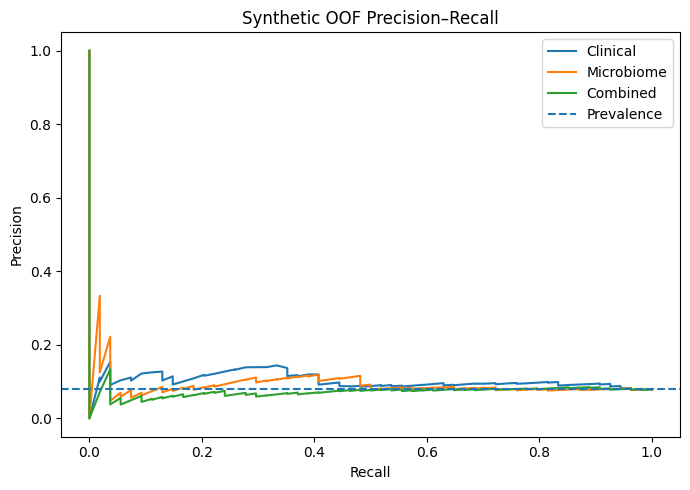

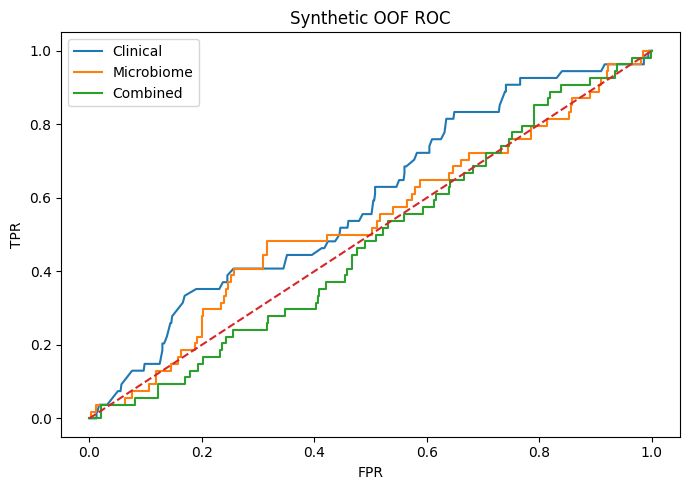

In [ ]:
# Figuras sem valor clínico; apenas OOF de pesquisa.
fig,ax=plt.subplots(figsize=(7,5))
for name,pred in [
    ("Clinical",S_PREDS["clinical"]),
    ("Microbiome",S_PREDS["micro"]),
    ("Combined",S_PREDS["combined"]),
]:
    precision,recall,_=precision_recall_curve(S_Y,pred)
    ax.plot(recall,precision,label=name)
ax.axhline(S_Y.mean(),linestyle="--",label="Prevalence")
ax.set_xlabel("Recall");ax.set_ylabel("Precision");ax.set_title("Synthetic OOF Precision–Recall")
ax.legend();fig.tight_layout()
fig.savefig(DIRS["figures"]/"synthetic_pr_oof.png",dpi=200)
plt.show()

fig,ax=plt.subplots(figsize=(7,5))
for name,pred in [
    ("Clinical",S_PREDS["clinical"]),
    ("Microbiome",S_PREDS["micro"]),
    ("Combined",S_PREDS["combined"]),
]:
    fpr,tpr,_=roc_curve(S_Y,pred)
    ax.plot(fpr,tpr,label=name)
ax.plot([0,1],[0,1],linestyle="--")
ax.set_xlabel("FPR");ax.set_ylabel("TPR");ax.set_title("Synthetic OOF ROC")
ax.legend();fig.tight_layout()
fig.savefig(DIRS["figures"]/"synthetic_roc_oof.png",dpi=200)
plt.show()

In [ ]:
# 26. Manifesto, relatório e bundle
import importlib.metadata as mdmeta

def version(pkg):
    try:return mdmeta.version(pkg)
    except Exception:return None

MANIFEST={
    "project":"OdontoCA","version":"1.3",
    "created_utc":datetime.now(timezone.utc).isoformat(),
    "profile":CFG.PROFILE,"config":asdict(CFG),
    "source_notebook_hashes":SOURCE_NOTEBOOK_HASHES,
    "methodological_patch":"fully_nested_microbiome_preprocessing",
    "runtime":{
        "python":platform.python_version(),"platform":platform.platform(),
        "numpy":np.__version__,"pandas":pd.__version__,
        "scipy":scipy.__version__,"scikit_learn":sklearn.__version__,
    },
    "targets":TARGETS,
    "synthetic":{
        "n":len(S_Y),"events":int(S_Y.sum()),
        "metrics":S_MODEL_METRICS.to_dict("records"),
        "ca_rule":S_CA_METRICS,
    },
    "real_clinical_loaded":REAL["clinical_audit"] is not None,
    "real_micro_loaded":REAL["micro_alignment_audit"] is not None,
    "image_audit_run":AUDIT_IMAGE_DATASET,
    "image_train_status":IMAGE_TRAIN_STATUS,
}
(DIRS["reports"]/"manifest.json").write_text(json.dumps(MANIFEST,indent=2,ensure_ascii=False,default=str))

TRACEABILITY.to_csv(DIRS["reports"]/"sdd_tdd_traceability.csv",index=False)
COMPLIANCE.to_csv(DIRS["reports"]/"compliance_audit.csv",index=False)
GATE_REPORT.to_csv(DIRS["reports"]/"acceptance_gates.csv",index=False)
S_MODEL_METRICS.to_csv(DIRS["models"]/"synthetic_model_metrics.csv",index=False)
S_FOLD_DETAILS.to_csv(DIRS["models"]/"synthetic_fold_details.csv",index=False)
S_CHANCE.to_csv(DIRS["models"]/"synthetic_below_chance.csv",index=False)
S_SCALE.to_csv(DIRS["models"]/"synthetic_cross_fold_scale.csv",index=False)
S_BOOT_SUMMARY.to_csv(DIRS["models"]/"synthetic_bootstrap_incremental_summary.csv",index=False)
(DIRS["exports"]/"fhir_riskassessment_example.json").write_text(json.dumps(FHIR_EXAMPLE,indent=2))

passes=int((TDD_REPORT["status"]=="PASS").sum())
skips=int((TDD_REPORT["status"]=="SKIP").sum())
fails=int((TDD_REPORT["status"]=="FAIL").sum())

report=f'''# OdontoCA v1.3 — Validation Report

## Engineering
- Profile: `{CFG.PROFILE}`
- TDD: {passes} PASS, {skips} SKIP, {fails} FAIL
- SDD coverage: {len(REQUIREMENTS)-len(UNMAPPED)}/{len(REQUIREMENTS)}
- Fully nested microbiome preprocessing: YES
- Positive class selected by estimator.classes_: YES
- Cross-cohort fusion guard: YES
- Below-chance post-hoc inversion: BLOCKED
- Bootstrap replicates requested: {BOOTSTRAPS}

## Synthetic integration smoke
{S_MODEL_METRICS.to_markdown(index=False)}

## Real-data status
- Clinical Table_S1 reproduction: {"RUN" if REAL["clinical_audit"] is not None else "NOT_RUN"}
- Qiita microbiome alignment: {"RUN" if REAL["micro_alignment_audit"] is not None else "NOT_RUN"}
- Image benchmark audit: {"RUN" if AUDIT_IMAGE_DATASET else "NOT_RUN"}
- Visual model training: {IMAGE_TRAIN_STATUS.get("status")}

## Scientific boundaries
- Plaque target: NOT_VALIDATED
- Definitive surface diagnosis: NOT_VALIDATED
- Cross-dataset synthetic fusion: PROHIBITED
- External clinical validation: NOT_PERFORMED
- FHIR: EXPERIMENTAL / preliminary
- Performance targets: monitored, not claimed
'''
(DIRS["reports"]/"VALIDATION_REPORT.md").write_text(report)
print(report)

bundle=BASE/"OdontoCA_v1_3_FULL_RESEARCH_RESULTS.zip"
if bundle.exists():bundle.unlink()
with zipfile.ZipFile(bundle,"w",zipfile.ZIP_DEFLATED) as z:
    for group in ["clinical","micro","image","models","figures","reports","tests","exports"]:
        for p in DIRS[group].rglob("*"):
            if p.is_file():
                z.write(p,p.relative_to(BASE))
print("Bundle:",bundle)

# OdontoCA v1.3 — Validation Report

## Engineering
- Profile: `CI_SMOKE`
- TDD: 24 PASS, 2 SKIP, 0 FAIL
- SDD coverage: 31/31
- Fully nested microbiome preprocessing: YES
- Positive class selected by estimator.classes_: YES
- Cross-cohort fusion guard: YES
- Below-chance post-hoc inversion: BLOCKED
- Bootstrap replicates requested: 200

## Synthetic integration smoke
| model                           |   n |   events |   prevalence |    PR_AUC |   ROC_AUC |     Brier |   LogLoss |
|:--------------------------------|----:|---------:|-------------:|----------:|----------:|----------:|----------:|
| Clinical_spatial_logistic       | 686 |       54 |    0.0787172 | 0.105386  |  0.590571 | 0.0733041 |  0.27961  |
| Microbiome_CLR_nested           | 686 |       54 |    0.0787172 | 0.0955304 |  0.532613 | 0.131119  |  0.431432 |
| Clinical_plus_microbiome_nested | 686 |       54 |    0.0787172 | 0.0748247 |  0.480397 | 0.0812242 |  0.325447 |

## Real-data status
- Clinical Table_S1 reproduc

# 27. Interpretação dos status

`VALIDATED-CI-SMOKE` significa que o notebook, o SDD, o TDD, a reconstrução
sintética, o CA, os três modelos nested, os guards de leakage, o bootstrap,
a auditoria below-chance e o FHIR executaram corretamente.

`REPRO-DATASET-PASS` exige executar `PROFILE="REPRO_DATASET"` e reproduzir
todas as contagens do Table_S1.

`MICROBIOME-RESEARCH-PASS` exige `PROFILE="MICROBIOME_RESEARCH"` e valida
SampleID × BIOM, bibliotecas não zeradas e nested CV real.

`FULL-RESEARCH-PASS` exige também o braço visual.

Nenhum desses estados equivale a `CLINICAL_VALIDATED`.

# 28. Adendo clínico v1.3.3 — validação interna exploratória

**Estado executado separadamente:** a análise abaixo foi executada sobre o suplemento clínico público Table S1, fixado no commit `e5868fe5` e verificado por SHA-256. Os resultados anteriores do perfil `CI_SMOKE` são sintéticos e não representam desempenho clínico.

**Coorte e alvo:** 997 transições H→H/H→C foram reconstruídas (84 eventos). Uma transição com intervalo de seguimento zero foi excluída: **996 transições, 83 eventos, 81 crianças**; seguimento de 2–5 meses. O alvo é incidência de cárie em um dente inicialmente hígido.

**Método:** dois modelos de regressão logística penalizada, mínimo clínico e clínico-espacial; cinco folds externos e três internos estratificados e agrupados por criança; seleção de regularização dentro do treino; 1.000 reamostragens bootstrap por criança das predições fora da amostra. A classe positiva é localizada explicitamente. Variáveis futuras, o desfecho e o intervalo de seguimento não entram como preditores.

| Modelo | AP | ROC-AUC | Brier | Inclinação de calibração |
|---|---:|---:|---:|---:|
| Clínico mínimo | 0,166 | 0,686 | 0,0806 | 0,516 |
| Clínico-espacial | 0,178 | 0,737 | 0,0754 | 0,605 |

A diferença de AP foi 0,012, com intervalo bootstrap de 95% de −0,046 a 0,058. Portanto, a vantagem do modelo espacial **não está estabelecida**. A calibração ainda precisa melhorar. Não houve validação externa, microbioma real pareado nem imagem clínica pareada. Nenhum resultado autoriza uso assistencial.

**Fluxo atualizado:** Table S1 pública → verificação de versão/hash → reconstrução dente-visita → exclusão de intervalo não positivo → atributos disponíveis em t → CV aninhada agrupada por criança → predições fora da amostra → discriminação, calibração e bootstrap → validação externa prospectiva antes de qualquer avaliação de uso clínico.

A célula seguinte reproduz a análise depois de executar as células anteriores de reconstrução longitudinal. Salva somente estatísticas agregadas e figuras em `/content/OdontoCA_v1_3/09_clinical_addendum`; não exporta registros individuais.


In [ ]:
"""Exploratory internal validation using the public OdontoCA source cohort.

The two candidate feature sets are fixed before examining model performance.
All preprocessing and regularisation selection occur within child-grouped
training folds. No microbiome or image data are used. Individual records and
identifiers are neither exported nor added to the manuscript directory.
"""

from __future__ import annotations

import hashlib
import json
import platform
from pathlib import Path
from io import BytesIO
import sys
import requests

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, log_loss,
    precision_recall_curve, roc_auc_score, roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from scipy.optimize import minimize, minimize_scalar
from scipy.special import expit, logit

SOURCE_COMMIT = "e5868fe5664460c7aac1c5b6d7980776ad26b29c"
SOURCE_URL = (
    "https://raw.githubusercontent.com/HuangShiLab/Single-tooth-ECC/"
    + SOURCE_COMMIT + "/Figures_and_Tables_in_Manuscript/Table_S1.xlsx"
)
SOURCE_SHA256 = "b7819fee81efbe2e227b7700c3cd86ce8bc6f7fe6f49da6214f4107d099184fa"


def fit_calibration(y, p):
    score = logit(np.clip(p, 1e-6, 1 - 1e-6))
    offset = minimize_scalar(
        lambda intercept: log_loss(y, expit(intercept + score), normalize=False),
        method="bounded", bounds=(-12, 12),
    )
    line = minimize(
        lambda coef: log_loss(y, expit(coef[0] + coef[1] * score), normalize=False),
        x0=np.array([0.0, 1.0]), method="BFGS",
    )
    if not np.isfinite(line.x).all():
        raise AssertionError("Nonfinite calibration coefficients")
    return {
        "mean_predicted": float(p.mean()),
        "observed_fraction": float(y.mean()),
        "calibration_in_the_large": float(offset.x),
        "calibration_slope": float(line.x[1]),
        "calibration_model_intercept": float(line.x[0]),
    }


OUT = Path(
    "/content/OdontoCA_v1_3/09_clinical_addendum"
    if "google.colab" in sys.modules else "/tmp/odonto_colab_addendum"
)
OUT.mkdir(parents=True, exist_ok=True)
SEED = 20260930
BOOTSTRAPS = 1000
FORBIDDEN = {
    "HostGroup", "host_group_source", "Future_Status_Tooth",
    "future_status_source_t", "Time_to_decay", "time_to_decay_source_t",
    "state_t1", "progression_event", "delta_months", "timepoint_t1",
}
FEATURE_SETS = {
    "clinical_minimal": {
        "cat": ["tooth_position"],
        "num": ["age_months_t", "host_dmfs_t", "neighbor_caries_count"],
    },
    "clinical_spatial": {
        "cat": ["tooth_position", "niche_icm", "niche_ul", "niche_lr", "niche_ap", "host_status_t"],
        "num": [
            "age_months_t", "host_dmfs_t", "neighbor_caries_count",
            "spatial_weighted_dmfs_t", "sum_dmfs_t", "sum_ns_dt_t", "sum_s_dt_t",
        ],
    },
}


def source_frame() -> tuple[pd.DataFrame, dict]:
    if not all(name in globals() for name in ("clean_single_tooth", "build_transitions")):
        raise RuntimeError("Execute as células anteriores de reconstrução longitudinal primeiro")
    response = requests.get(SOURCE_URL, timeout=90)
    response.raise_for_status()
    content = response.content
    digest = hashlib.sha256(content).hexdigest()
    if digest != SOURCE_SHA256:
        raise RuntimeError("O hash SHA-256 do suplemento clínico é diferente do auditado")
    meta = pd.read_excel(BytesIO(content), sheet_name="all_metadata")
    meta.columns = [str(col).strip() for col in meta.columns]
    _, _, clean = clean_single_tooth(meta)
    _, _, onset = build_transitions(clean)
    onset = onset.copy()
    onset["neighbor_caries_count"] = (
        onset["neighbor_prev_state_t"].eq("C").astype(int)
        + onset["neighbor_next_state_t"].eq("C").astype(int)
    )
    if len(onset) != 997 or int(onset["progression_event"].sum()) != 84:
        raise AssertionError("As contagens da coorte de origem não foram reproduzidas")
    zero_interval = onset.loc[onset["delta_months"].le(0)]
    frame = onset.loc[onset["delta_months"].gt(0)].reset_index(drop=True)
    if len(frame) != 996 or int(frame["progression_event"].sum()) != 83:
        raise AssertionError("A coorte analítica com seguimento positivo mudou")
    return frame, {
        "source_sha256": digest,
        "reproduced_eligible": 997,
        "reproduced_events": 84,
        "excluded_nonpositive_followup_interval": len(zero_interval),
        "excluded_events": int(zero_interval["progression_event"].sum()),
    }


def build_pipeline(categories: list[str], numeric: list[str]) -> Pipeline:
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)
    prep = ColumnTransformer(
        [
            ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", onehot)]), categories),
            ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric),
        ],
        remainder="drop", sparse_threshold=0,
    )
    return Pipeline([
        ("prep", prep),
        ("model", LogisticRegression(penalty="l2", solver="liblinear", max_iter=5000)),
    ])


def interval(values: list[float]) -> list[float]:
    return [float(v) for v in np.quantile(values, [0.025, 0.975])]


def run() -> None:
    frame, source = source_frame()
    y = frame["progression_event"].to_numpy(dtype=int)
    groups = frame["child_id"].astype(str).to_numpy()
    for definition in FEATURE_SETS.values():
        if FORBIDDEN.intersection(definition["cat"] + definition["num"]):
            raise AssertionError("A future or outcome-derived variable entered the model")

    predictions = {name: np.full(len(frame), np.nan) for name in FEATURE_SETS}
    prevalence_reference = np.full(len(frame), np.nan)
    fold_assignment = np.full(len(frame), -1)
    fold_log = []
    outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    for fold, (train, test) in enumerate(outer.split(frame, y, groups)):
        if not set(groups[train]).isdisjoint(groups[test]):
            raise AssertionError("Child overlap across outer folds")
        if len(np.unique(y[test])) != 2:
            raise AssertionError("Outer test fold lacks one outcome class")
        prevalence_reference[test] = y[train].mean()
        inner = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED + 100 + fold)
        log = {
            "fold": fold,
            "train_rows": len(train), "test_rows": len(test),
            "train_children": len(set(groups[train])), "test_children": len(set(groups[test])),
            "train_events": int(y[train].sum()), "test_events": int(y[test].sum()),
        }
        for name, definition in FEATURE_SETS.items():
            columns = definition["cat"] + definition["num"]
            search = GridSearchCV(
                build_pipeline(definition["cat"], definition["num"]),
                {"model__C": [0.01, 0.1, 1.0, 10.0]},
                scoring="average_precision", cv=inner, n_jobs=1,
                refit=True, error_score="raise",
            )
            search.fit(frame.iloc[train][columns], y[train], groups=groups[train])
            classes = search.best_estimator_.named_steps["model"].classes_
            positive = np.flatnonzero(classes == 1)
            if len(positive) != 1:
                raise AssertionError("Positive class is absent or ambiguous")
            predictions[name][test] = search.predict_proba(frame.iloc[test][columns])[:, int(positive[0])]
            log[name + "_C"] = search.best_params_["model__C"]
        fold_assignment[test] = fold
        fold_log.append(log)

    if pd.DataFrame({"child": groups, "fold": fold_assignment}).groupby("child")["fold"].nunique().max() != 1:
        raise AssertionError("Grouped validation invariant failed")
    if not all(np.isfinite(p).all() and ((p >= 0) & (p <= 1)).all() for p in predictions.values()):
        raise AssertionError("Invalid out-of-fold probability")

    metrics = {}
    for name, p in predictions.items():
        metrics[name] = {
            "pr_auc": float(average_precision_score(y, p)),
            "roc_auc": float(roc_auc_score(y, p)),
            "brier": float(brier_score_loss(y, p)),
            "log_loss": float(log_loss(y, np.clip(p, 1e-6, 1 - 1e-6))),
            **fit_calibration(y, p),
        }

    rng = np.random.default_rng(SEED + 1)
    children = np.unique(groups)
    child_indices = {child: np.flatnonzero(groups == child) for child in children}
    sampled_metrics = {name: {metric: [] for metric in ["pr_auc", "roc_auc", "brier"]} for name in predictions}
    sampled_deltas = {metric: [] for metric in ["pr_auc", "roc_auc", "brier"]}
    valid = 0
    for _ in range(BOOTSTRAPS):
        sampled = rng.choice(children, size=len(children), replace=True)
        index = np.concatenate([child_indices[child] for child in sampled])
        yy = y[index]
        if len(np.unique(yy)) != 2:
            continue
        valid += 1
        for name, p in predictions.items():
            pp = p[index]
            sampled_metrics[name]["pr_auc"].append(float(average_precision_score(yy, pp)))
            sampled_metrics[name]["roc_auc"].append(float(roc_auc_score(yy, pp)))
            sampled_metrics[name]["brier"].append(float(brier_score_loss(yy, pp)))
        for metric in sampled_deltas:
            sampled_deltas[metric].append(
                sampled_metrics["clinical_spatial"][metric][-1]
                - sampled_metrics["clinical_minimal"][metric][-1]
            )
    for name in metrics:
        for metric, values in sampled_metrics[name].items():
            metrics[name][metric + "_ci95"] = interval(values)
    differences = {
        metric: {
            "estimate": metrics["clinical_spatial"][metric] - metrics["clinical_minimal"][metric],
            "ci95": interval(values),
        }
        for metric, values in sampled_deltas.items()
    }

    report = {
        "analysis_status": "EXPLORATORY_INTERNAL_VALIDATION_ONLY",
        "source": source,
        "source_commit": SOURCE_COMMIT,
                "runtime": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "scipy": scipy.__version__,
            "scikit_learn": sklearn.__version__,
        },
        "analysis_rows": len(frame),
        "analysis_events": int(y.sum()),
        "analysis_children": len(children),
        "event_children": int(frame.loc[frame["progression_event"].eq(1), "child_id"].nunique()),
        "event_fraction": float(y.mean()),
        "followup_months_median": float(frame["delta_months"].median()),
        "followup_months_iqr": [float(v) for v in frame["delta_months"].quantile([0.25, 0.75])],
        "followup_months_range": [float(frame["delta_months"].min()), float(frame["delta_months"].max())],
        "seed": SEED, "outer_folds": 5, "inner_folds": 3,
        "feature_sets": FEATURE_SETS,
        "fold_log": fold_log,
        "child_disjoint_outer_folds": True,
        "bootstrap_requested": BOOTSTRAPS, "bootstrap_valid": valid,
        "metrics": metrics,
        "prevalence_reference": {
            "brier": float(brier_score_loss(y, prevalence_reference)),
            "log_loss": float(log_loss(y, prevalence_reference)),
        },
        "spatial_minus_minimal": differences,
        "scope_note": (
            "This is internal validation in one public cohort with no external test, "
            "real microbiome alignment or image branch. Patient use is unsupported."
        ),
    }
    (OUT / "real_clinical_internal_validation.json").write_text(json.dumps(report, ensure_ascii=False, indent=2))

    plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), dpi=170)
    colors = {"clinical_minimal": "#25668c", "clinical_spatial": "#bf7924"}
    for name, p in predictions.items():
        precision, recall, _ = precision_recall_curve(y, p)
        fpr, tpr, _ = roc_curve(y, p)
        label = "Minimal clinical" if name == "clinical_minimal" else "Clinical + spatial"
        axes[0].plot(recall, precision, label=f"{label} (AP {metrics[name]['pr_auc']:.3f})", color=colors[name], lw=2)
        axes[1].plot(fpr, tpr, label=f"{label} (AUC {metrics[name]['roc_auc']:.3f})", color=colors[name], lw=2)
    axes[0].axhline(y.mean(), color="#777777", ls="--", label=f"Event fraction {y.mean():.3f}")
    axes[1].plot([0, 1], [0, 1], color="#777777", ls="--", label="Chance")
    axes[0].set(xlabel="Recall", ylabel="Precision", title="A. Precision–recall")
    axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="B. ROC")
    for ax in axes:
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="best", frameon=False, fontsize=8)
    fig.suptitle("Public clinical cohort: child-grouped internal out-of-fold predictions", fontsize=12)
    fig.tight_layout()
    fig.savefig(OUT / "Figure_2_real_internal_validation.png", bbox_inches="tight")
    fig.savefig(OUT / "Figure_2_real_internal_validation.pdf", bbox_inches="tight")
    plt.close(fig)

    # Descriptive calibration only: each point pools one fifth of observations
    # ordered by out-of-fold predicted probability, without outcome fitting.
    fig, ax = plt.subplots(figsize=(5.5, 5.0), dpi=170)
    max_bin_value = 0.0
    for name, p in predictions.items():
        ordered = np.argsort(p)
        bins = np.array_split(ordered, 5)
        mean_pred = [float(p[part].mean()) for part in bins]
        observed = [float(y[part].mean()) for part in bins]
        max_bin_value = max(max_bin_value, *mean_pred, *observed)
        label = "Minimal clinical" if name == "clinical_minimal" else "Clinical + spatial"
        ax.plot(mean_pred, observed, marker="o", color=colors[name], lw=2, label=label)
    axis_max = min(1.0, max_bin_value * 1.12)
    ax.plot([0, axis_max], [0, axis_max], ls="--", color="#777777", label="Ideal calibration")
    ax.set(xlim=(0, axis_max), ylim=(0, axis_max), xlabel="Mean predicted risk", ylabel="Observed event fraction",
           title="Internal calibration, five equal-count bins")
    ax.legend(loc="upper left", frameon=False, fontsize=8)
    fig.subplots_adjust(left=0.19, right=0.98, top=0.93, bottom=0.15)
    fig.savefig(OUT / "Figure_3_real_internal_calibration.png", bbox_inches="tight")
    fig.savefig(OUT / "Figure_3_real_internal_calibration.pdf", bbox_inches="tight")
    plt.close(fig)

    print(json.dumps({
        "analysis_rows": report["analysis_rows"],
        "analysis_events": report["analysis_events"],
        "analysis_children": report["analysis_children"],
        "event_fraction": report["event_fraction"],
        "metrics": metrics,
        "prevalence_reference": report["prevalence_reference"],
        "spatial_minus_minimal": differences,
    }, ensure_ascii=False, indent=2))


if __name__ == "__main__":
    run()


# 29. Recalibração aninhada por criança — análise corrigida

**Correção da validação:** o resultado anterior (AP 0,2318/0,2414) é reproduzível no scikit-learn 1.6.1, porém `StratifiedGroupKFold(shuffle=True)` dessa versão pode desalinhar as contagens de classe e os grupos. A célula abaixo reproduz a lógica corrigida da divisão em qualquer uma das versões testadas, por permutação explícita de rótulos de grupo seguida de `shuffle=False`. Com essa divisão corrigida, os resultados-base são AP 0,1665/0,1784 e ROC-AUC 0,6865/0,7372 para os modelos mínimo/espacial. A mudança nos números decorre da divisão das crianças, sem representar piora ou melhora biológica.

**Calibração sem vazamento:** em cada uma das cinco dobras externas, o C é escolhido nas três dobras internas. As previsões cruzadas internas treinam dois mapas de risco: intercepto apenas e intercepto mais inclinação. Eles são aplicados somente ao teste externo. O ajuste do mapa não usa os rótulos das crianças do teste externo. Os intervalos das diferenças vêm de bootstrap pareado por criança das previsões externas já ajustadas.

| Modelo | Probabilidade | AP | ROC-AUC | Brier | Log-loss |
|---|---|---:|---:|---:|---:|
| Clínico mínimo | Original corrigido | 0,1665 | 0,6865 | 0,08060 | 0,28836 |
| Clínico mínimo | Intercepto + inclinação | 0,1920 | 0,7153 | 0,07451 | 0,26802 |
| Clínico espacial | Original corrigido | 0,1784 | 0,7372 | 0,07536 | 0,26899 |
| Clínico espacial | Intercepto + inclinação | 0,1759 | 0,7387 | 0,07395 | 0,26381 |

No modelo mínimo, a diferença de Brier (recalibrado − original) foi −0,00610, IC95% bootstrap por criança [−0,01173; −0,000672]. A melhora dos demais desfechos e do modelo espacial requer cautela; não há validação externa nem evidência de utilidade clínica. Esta é uma análise exploratória posterior à avaliação original. A saída contém somente métricas agregadas e figuras, em `/content/OdontoCA_v1_3/10_calibracao`.


In [ ]:
"""Nested, child-grouped evaluation of train-only probability recalibration.

The scikit-learn 1.6.1 split policy reproduces the Colab analysis; 1.9.0
provides a sensitivity analysis with corrected stratified splitting. Only
aggregate statistics and figures are written; no individual predictions or
patient identifiers leave this process.
"""

from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.optimize import minimize, minimize_scalar
from scipy.special import expit, logit
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold

# Cohort reconstruction and base-model functions are supplied by the preceding cell.


OUT = Path("/content/OdontoCA_v1_3/10_calibracao" if "google.colab" in sys.modules else "/tmp/odonto_colab_calibrated")
OUT.mkdir(parents=True, exist_ok=True)
METHODS = ("uncalibrated", "intercept_only", "intercept_and_slope")
VERSION_TAG = sklearn.__version__.replace(".", "")
SPLIT_POLICY = "corrected_permuted_groups"


def corrected_group_splits(X, y, groups, n_splits: int, seed: int):
    """Reproduce the corrected shuffle algorithm across sklearn versions.

    Permuting numeric group labels before shuffle=False yields the same stable
    tie order as the corrected shuffle=True implementation, while retaining
    the label-to-group mapping in affected older versions.
    """
    _, group_inverse = np.unique(groups, return_inverse=True)
    permutation = np.arange(int(group_inverse.max()) + 1)
    np.random.RandomState(seed).shuffle(permutation)
    inverse_permutation = np.empty_like(permutation)
    inverse_permutation[permutation] = np.arange(permutation.size)
    relabelled = inverse_permutation[group_inverse]
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=False)
    return list(splitter.split(X, y, relabelled))


def _score(p: np.ndarray) -> np.ndarray:
    return logit(np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6))


def fit_recalibrators(y: np.ndarray, p: np.ndarray) -> dict[str, dict[str, float]]:
    """Fit two monotone maps using training-only cross-fitted probabilities."""
    y = np.asarray(y, dtype=int)
    x = _score(p)
    if len(np.unique(y)) != 2 or not np.isfinite(x).all():
        raise ValueError("Calibration training data need both outcomes and finite scores")
    offset = minimize_scalar(
        lambda a: log_loss(y, expit(a + x), normalize=False),
        method="bounded", bounds=(-12, 12),
    )
    if not offset.success:
        raise RuntimeError("Intercept recalibration failed")
    # The positive slope constraint keeps the map monotone in risk.
    line = minimize(
        lambda ab: log_loss(y, expit(ab[0] + ab[1] * x), normalize=False),
        x0=np.array([float(offset.x), 1.0]),
        method="L-BFGS-B", bounds=[(-12, 12), (0.05, 3.0)],
    )
    if not line.success or not np.isfinite(line.x).all():
        raise RuntimeError("Intercept-and-slope recalibration failed")
    return {
        "intercept_only": {"intercept": float(offset.x), "slope": 1.0},
        "intercept_and_slope": {
            "intercept": float(line.x[0]), "slope": float(line.x[1]),
        },
    }


def apply_recalibration(p: np.ndarray, parameters: dict[str, float]) -> np.ndarray:
    return expit(parameters["intercept"] + parameters["slope"] * _score(p))


def _metrics(y: np.ndarray, p: np.ndarray) -> dict[str, float]:
    return {
        "pr_auc": float(average_precision_score(y, p)),
        "roc_auc": float(roc_auc_score(y, p)),
        "brier": float(brier_score_loss(y, p)),
        "log_loss": float(log_loss(y, np.clip(p, 1e-6, 1 - 1e-6))),
        **fit_calibration(y, p),
    }


def _reliability(ax, y: np.ndarray, p: np.ndarray, label: str, color: str) -> None:
    boundaries = np.unique(np.quantile(p, np.linspace(0, 1, 9)))
    if len(boundaries) < 3:
        return
    bins = np.digitize(p, boundaries[1:-1], right=True)
    px = [p[bins == k].mean() for k in range(len(boundaries) - 1) if (bins == k).any()]
    py = [y[bins == k].mean() for k in range(len(boundaries) - 1) if (bins == k).any()]
    ax.plot(px, py, "o-", lw=1.5, ms=4, label=label, color=color)


def _figures(y: np.ndarray, predictions: dict[str, dict[str, np.ndarray]], metrics: dict) -> None:
    colors = {"clinical_minimal": "#25668c", "clinical_spatial": "#bf7924"}
    labels = {"clinical_minimal": "Minimal clinical", "clinical_spatial": "Clinical + spatial"}
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), dpi=170)
    for name, variants in predictions.items():
        p = variants["uncalibrated"]
        precision, recall, _ = precision_recall_curve(y, p)
        fpr, tpr, _ = roc_curve(y, p)
        axes[0].plot(recall, precision, label=f"{labels[name]} (AP {metrics[name]['uncalibrated']['pr_auc']:.3f})", color=colors[name], lw=2)
        axes[1].plot(fpr, tpr, label=f"{labels[name]} (AUC {metrics[name]['uncalibrated']['roc_auc']:.3f})", color=colors[name], lw=2)
    axes[0].axhline(y.mean(), ls="--", color="#777", label=f"Event fraction {y.mean():.3f}")
    axes[1].plot([0, 1], [0, 1], ls="--", color="#777", label="Chance")
    axes[0].set(xlabel="Recall", ylabel="Precision", title="A. Precision–recall")
    axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="B. ROC")
    for ax in axes:
        ax.legend(fontsize=8)
        ax.grid(alpha=0.15)
    fig.tight_layout()
    fig.savefig(OUT / f"Figure_2_discrimination_corrected_sklearn{VERSION_TAG}.png", bbox_inches="tight")
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), dpi=170)
    method_labels = {
        "uncalibrated": "Original", "intercept_only": "Intercept updated",
        "intercept_and_slope": "Intercept and slope updated",
    }
    method_colors = {
        "uncalibrated": "#69747c", "intercept_only": "#25668c",
        "intercept_and_slope": "#bf7924",
    }
    for ax, (name, variants) in zip(axes, predictions.items()):
        ax.plot([0, 0.5], [0, 0.5], ls="--", color="#333", lw=1, label="Ideal")
        for method, p in variants.items():
            _reliability(ax, y, p, method_labels[method], method_colors[method])
        ax.set(xlim=(0, 0.5), ylim=(0, 0.5), xlabel="Mean predicted risk", ylabel="Observed event fraction", title=labels[name])
        ax.grid(alpha=0.15)
        ax.legend(fontsize=7)
    fig.tight_layout()
    fig.savefig(OUT / f"Figure_3_calibration_corrected_sklearn{VERSION_TAG}.png", bbox_inches="tight")
    plt.close(fig)


def run_calibrated() -> dict:
    frame, source = source_frame()
    y = frame["progression_event"].to_numpy(dtype=int)
    groups = frame["child_id"].astype(str).to_numpy()
    if any(FORBIDDEN.intersection(d["cat"] + d["num"]) for d in FEATURE_SETS.values()):
        raise AssertionError("Future/outcome-derived variable entered the model")
    predictions = {
        name: {method: np.full(len(y), np.nan) for method in METHODS}
        for name in FEATURE_SETS
    }
    fold_ids = np.full(len(y), -1)
    folds = []
    prevalence = np.full(len(y), np.nan)
    outer_splits = corrected_group_splits(frame, y, groups, n_splits=5, seed=SEED)
    for fold, (train, test) in enumerate(outer_splits):
        if not set(groups[train]).isdisjoint(groups[test]) or len(np.unique(y[test])) != 2:
            raise AssertionError("Outer child separation or outcome balance failed")
        prevalence[test] = y[train].mean()
        fold_ids[test] = fold
        detail = {
            "fold": fold, "train_rows": len(train), "test_rows": len(test),
            "train_children": len(set(groups[train])), "test_children": len(set(groups[test])),
            "train_events": int(y[train].sum()), "test_events": int(y[test].sum()),
        }
        splits = corrected_group_splits(
            frame.iloc[train], y[train], groups[train],
            n_splits=3, seed=SEED + 100 + fold,
        )
        if any(not set(groups[train][a]).isdisjoint(groups[train][b]) for a, b in splits):
            raise AssertionError("Inner child separation failed")
        for name, definition in FEATURE_SETS.items():
            columns = definition["cat"] + definition["num"]
            xtrain, xtest = frame.iloc[train][columns], frame.iloc[test][columns]
            search = GridSearchCV(
                build_pipeline(definition["cat"], definition["num"]),
                {"model__C": [0.01, 0.1, 1.0, 10.0]},
                scoring="average_precision", cv=splits, n_jobs=1,
                refit=True, error_score="raise",
            )
            search.fit(xtrain, y[train])
            chosen_c = search.best_params_["model__C"]
            positive = np.flatnonzero(search.best_estimator_.classes_ == 1)
            if len(positive) != 1:
                raise AssertionError("Positive outcome class is ambiguous")
            raw_test = search.predict_proba(xtest)[:, int(positive[0])]
            predictions[name]["uncalibrated"][test] = raw_test

            # Calibration sees only cross-fitted predictions from this outer TRAIN.
            inner_oof = np.full(len(train), np.nan)
            for a, b in splits:
                model = build_pipeline(definition["cat"], definition["num"])
                model.set_params(model__C=chosen_c)
                model.fit(xtrain.iloc[a], y[train][a])
                positive_inner = np.flatnonzero(model.classes_ == 1)
                if len(positive_inner) != 1:
                    raise AssertionError("Inner positive class is ambiguous")
                inner_oof[b] = model.predict_proba(xtrain.iloc[b])[:, int(positive_inner[0])]
            if not np.isfinite(inner_oof).all():
                raise AssertionError("Incomplete inner cross-fitting")
            recalibrators = fit_recalibrators(y[train], inner_oof)
            for method, params in recalibrators.items():
                predictions[name][method][test] = apply_recalibration(raw_test, params)
            detail[name + "_C"] = chosen_c
            detail[name + "_calibration"] = recalibrators
        folds.append(detail)

    if (fold_ids < 0).any() or pd.DataFrame({"child": groups, "fold": fold_ids}).groupby("child")["fold"].nunique().max() != 1:
        raise AssertionError("Outer grouped OOF coverage failed")
    if any(not np.isfinite(p).all() or ((p < 0) | (p > 1)).any() for v in predictions.values() for p in v.values()):
        raise AssertionError("Invalid external-fold probability")
    metrics = {name: {method: _metrics(y, p) for method, p in variants.items()} for name, variants in predictions.items()}

    # Paired child bootstrap conditions on the already cross-fitted predictions.
    rng = np.random.default_rng(SEED + 1)
    children = np.unique(groups)
    child_indices = {child: np.flatnonzero(groups == child) for child in children}
    differences = {
        name: {method: {metric: [] for metric in ("brier", "log_loss")}
               for method in METHODS if method != "uncalibrated"}
        for name in FEATURE_SETS
    }
    valid = 0
    for _ in range(BOOTSTRAPS):
        sampled = rng.choice(children, size=len(children), replace=True)
        index = np.concatenate([child_indices[child] for child in sampled])
        yy = y[index]
        if len(np.unique(yy)) != 2:
            continue
        valid += 1
        for name, variants in predictions.items():
            raw = variants["uncalibrated"][index]
            for method in differences[name]:
                calibrated = variants[method][index]
                differences[name][method]["brier"].append(float(brier_score_loss(yy, calibrated) - brier_score_loss(yy, raw)))
                differences[name][method]["log_loss"].append(float(log_loss(yy, calibrated) - log_loss(yy, raw)))
    delta_report = {
        name: {
            method: {
                metric: {
                    "estimate": metrics[name][method][metric] - metrics[name]["uncalibrated"][metric],
                    "ci95": interval(values),
                }
                for metric, values in by_metric.items()
            }
            for method, by_metric in by_method.items()
        }
        for name, by_method in differences.items()
    }
    report = {
        "analysis_status": "EXPLORATORY_INTERNAL_VALIDATION_ONLY",
        "source": source,
        "runtime": {
            "python": platform.python_version(), "numpy": np.__version__,
            "pandas": pd.__version__, "scipy": scipy.__version__,
            "scikit_learn": sklearn.__version__,
        },
        "analysis_rows": len(y), "analysis_events": int(y.sum()),
        "analysis_children": len(children),
        "event_children": len(np.unique(groups[y == 1])),
        "event_fraction": float(y.mean()),
        "seed": SEED, "outer_folds": 5, "inner_folds": 3,
        "split_policy": SPLIT_POLICY,
        "fold_log": folds,
        "metrics": metrics,
        "prevalence_reference": {
            "brier": float(brier_score_loss(y, prevalence)),
            "log_loss": float(log_loss(y, prevalence)),
        },
        "calibration_minus_uncalibrated": delta_report,
        "bootstrap_requested": BOOTSTRAPS, "bootstrap_valid": valid,
        "scope_note": "Cross-fitted internal calibration within 81 children; no external validation or clinical use.",
    }
    path = OUT / f"calibrated_clinical_internal_validation_corrected_sklearn{VERSION_TAG}.json"
    path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
    _figures(y, predictions, metrics)
    print(json.dumps({"metrics": metrics, "calibration_minus_uncalibrated": delta_report}, ensure_ascii=False, indent=2))
    return report


run_calibrated()
